In [1]:
# Import libraries and define configs
import json
import random
import warnings
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import resample

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "figure.dpi": 120,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "legend.fontsize": 10,
    }
)

RANDOM_STATE = 121
N_JOBS = -1
CV_FOLDS = 5
OPERATING_THRESHOLD = 0.065424
OUTREACH_CAPACITIES = (0.01, 0.05, 0.10, 0.20)
PERMUTATION_IMPORTANCE_REPEATS = 30
PERMUTATION_IMPORTANCE_N_JOBS = -1
SHAP_FEATURE_PERTURBATION = "tree_path_dependent"
SHAP_MODEL_OUTPUT = "raw"
SHAP_ADDITIVITY_TOLERANCE = 1e-8
DIRECTION_MINIMUM_CORRELATION = 0.05
DIRECTION_NEUTRAL_SHAP_TOLERANCE = 0.0001

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

current_directory = Path.cwd().resolve()
project_root_candidates = [current_directory, *current_directory.parents]

PROJECT_ROOT = next(
    (
        candidate_directory
        for candidate_directory in project_root_candidates
        if (candidate_directory / "data" / "processed").exists()
        and (candidate_directory / "notebooks").exists()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the project root containing data/processed and notebooks."
    )

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
MODELING_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "modeling"
PRIVATE_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "private"
INTERPRETABILITY_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "interpretability"

INTERPRETABILITY_TABLES_DIR = INTERPRETABILITY_OUTPUT_DIR / "tables"
INTERPRETABILITY_FIGURES_DIR = INTERPRETABILITY_OUTPUT_DIR / "figures"

INTERPRETABILITY_TABLES_DIR.mkdir(parents=True, exist_ok=True)
INTERPRETABILITY_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DONOR_FEATURES_PARQUET_PATH = PROCESSED_DATA_DIR / "donor_features.parquet"
DONOR_FEATURES_CSV_PATH = PROCESSED_DATA_DIR / "donor_features.csv"
FEATURE_DICTIONARY_PATH = REPORTS_DIR / "feature_dictionary.csv"

PRIMARY_PIPELINE_PATH = MODELS_DIR / "final_primary_pipeline.joblib"
BENCHMARK_PIPELINE_PATH = (
    MODELS_DIR / "historical_donor_status_benchmark_pipeline.joblib"
)

FINAL_MODEL_CONFIGURATION_PATH = (
    MODELING_OUTPUT_DIR / "final_model_configuration.json"
)
FINAL_FEATURE_LISTS_PATH = MODELING_OUTPUT_DIR / "final_feature_lists.json"
FINAL_TEST_PREDICTIONS_PATH = (
    PRIVATE_OUTPUT_DIR / "primary_donor_predictions_final_test.csv"
)
PRIMARY_TEST_METRICS_PATH = (
    MODELING_OUTPUT_DIR / "primary_final_test_metrics.csv"
)
PRIMARY_OUTREACH_RESULTS_PATH = (
    MODELING_OUTPUT_DIR / "primary_final_test_outreach_results.csv"
)
BENCHMARK_TEST_METRICS_PATH = (
    MODELING_OUTPUT_DIR / "benchmark_test_metrics.csv"
)
MODELING_ARTIFACT_MANIFEST_PATH = (
    MODELING_OUTPUT_DIR / "modeling_artifact_manifest.csv"
)

In [2]:
print(f"Project root: {PROJECT_ROOT.name}")
print(f"Random state: {RANDOM_STATE}")
print(f"Operating threshold: {OPERATING_THRESHOLD:.6f}")
print("Phase 6 interpretability setup complete.")

Project root: red-cross-donor-prediction
Random state: 121
Operating threshold: 0.065424
Phase 6 interpretability setup complete.


In [3]:
# Load models, metadata, predicts, and eval artifacts
BENCHMARK_MODEL_COMPARISON_PATH = (
    MODELING_OUTPUT_DIR / "benchmark_model_comparison.csv"
)

required_phase5_artifact_paths = {
    "Primary model pipeline": PRIMARY_PIPELINE_PATH,
    "Benchmark model pipeline": BENCHMARK_PIPELINE_PATH,
    "Final model configuration": FINAL_MODEL_CONFIGURATION_PATH,
    "Final feature lists": FINAL_FEATURE_LISTS_PATH,
    "Feature dictionary": FEATURE_DICTIONARY_PATH,
    "Primary test predictions": FINAL_TEST_PREDICTIONS_PATH,
    "Primary test metrics": PRIMARY_TEST_METRICS_PATH,
    "Primary outreach results": PRIMARY_OUTREACH_RESULTS_PATH,
    "Benchmark model comparison": BENCHMARK_MODEL_COMPARISON_PATH,
    "Benchmark test metrics": BENCHMARK_TEST_METRICS_PATH,
    "Modeling artifact manifest": MODELING_ARTIFACT_MANIFEST_PATH,
}

missing_phase5_artifacts = {
    artifact_name: artifact_path
    for artifact_name, artifact_path in required_phase5_artifact_paths.items()
    if not artifact_path.exists()
}

if missing_phase5_artifacts:
    missing_artifact_list = "\n".join(
        f"- {artifact_name}: {artifact_path.relative_to(PROJECT_ROOT)}"
        for artifact_name, artifact_path in missing_phase5_artifacts.items()
    )
    raise FileNotFoundError(
        f"Required Phase 5 artifacts were not found:\n{missing_artifact_list}"
    )

model_primary_pipeline_final = joblib.load(PRIMARY_PIPELINE_PATH)
model_benchmark_pipeline_final = joblib.load(BENCHMARK_PIPELINE_PATH)

with FINAL_MODEL_CONFIGURATION_PATH.open("r", encoding="utf-8") as file:
    configuration_final_model = json.load(file)

with FINAL_FEATURE_LISTS_PATH.open("r", encoding="utf-8") as file:
    feature_sets_final = json.load(file)

metadata_feature_dictionary = pd.read_csv(FEATURE_DICTIONARY_PATH)
predictions_primary_final_test = pd.read_csv(FINAL_TEST_PREDICTIONS_PATH)

tracking_primary_final_test_donor_ids = (
    predictions_primary_final_test.loc[:, ["donor_unique_id"]].copy()
)

metrics_primary_final_test = pd.read_csv(PRIMARY_TEST_METRICS_PATH)
metrics_primary_outreach = pd.read_csv(PRIMARY_OUTREACH_RESULTS_PATH)
comparison_benchmark_models = pd.read_csv(BENCHMARK_MODEL_COMPARISON_PATH)
metrics_benchmark_final_test = pd.read_csv(BENCHMARK_TEST_METRICS_PATH)
manifest_modeling_artifacts = pd.read_csv(MODELING_ARTIFACT_MANIFEST_PATH)

primary_pipeline_steps = getattr(
    model_primary_pipeline_final,
    "named_steps",
    {},
)
benchmark_pipeline_steps = getattr(
    model_benchmark_pipeline_final,
    "named_steps",
    {},
)

preprocessor_primary_model_final = primary_pipeline_steps.get("preprocessor")
preprocessor_benchmark_model_final = benchmark_pipeline_steps.get("preprocessor")

if preprocessor_primary_model_final is None:
    primary_preprocessor_candidates = [
        pipeline_step
        for pipeline_step in primary_pipeline_steps.values()
        if hasattr(pipeline_step, "transformers_")
    ]

    if len(primary_preprocessor_candidates) == 1:
        preprocessor_primary_model_final = primary_preprocessor_candidates[0]
    else:
        raise KeyError(
            "The fitted primary preprocessing step could not be identified."
        )

if preprocessor_benchmark_model_final is None:
    benchmark_preprocessor_candidates = [
        pipeline_step
        for pipeline_step in benchmark_pipeline_steps.values()
        if hasattr(pipeline_step, "transformers_")
    ]

    if len(benchmark_preprocessor_candidates) == 1:
        preprocessor_benchmark_model_final = benchmark_preprocessor_candidates[0]
    else:
        raise KeyError(
            "The fitted benchmark preprocessing step could not be identified."
        )

loaded_artifact_summary = pd.DataFrame(
    [
        {
            "Artifact": "Primary model pipeline",
            "Object Type": type(model_primary_pipeline_final).__name__,
            "Rows": pd.NA,
            "Columns": pd.NA,
            "Source": PRIMARY_PIPELINE_PATH.relative_to(PROJECT_ROOT).as_posix(),
        },
        {
            "Artifact": "Benchmark model pipeline",
            "Object Type": type(model_benchmark_pipeline_final).__name__,
            "Rows": pd.NA,
            "Columns": pd.NA,
            "Source": BENCHMARK_PIPELINE_PATH.relative_to(PROJECT_ROOT).as_posix(),
        },
        {
            "Artifact": "Feature dictionary",
            "Object Type": type(metadata_feature_dictionary).__name__,
            "Rows": metadata_feature_dictionary.shape[0],
            "Columns": metadata_feature_dictionary.shape[1],
            "Source": FEATURE_DICTIONARY_PATH.relative_to(PROJECT_ROOT).as_posix(),
        },
        {
            "Artifact": "Primary final-test predictions",
            "Object Type": type(predictions_primary_final_test).__name__,
            "Rows": predictions_primary_final_test.shape[0],
            "Columns": predictions_primary_final_test.shape[1],
            "Source": FINAL_TEST_PREDICTIONS_PATH.relative_to(
                PROJECT_ROOT
            ).as_posix(),
        },
        {
            "Artifact": "Primary final-test metrics",
            "Object Type": type(metrics_primary_final_test).__name__,
            "Rows": metrics_primary_final_test.shape[0],
            "Columns": metrics_primary_final_test.shape[1],
            "Source": PRIMARY_TEST_METRICS_PATH.relative_to(
                PROJECT_ROOT
            ).as_posix(),
        },
        {
            "Artifact": "Primary outreach results",
            "Object Type": type(metrics_primary_outreach).__name__,
            "Rows": metrics_primary_outreach.shape[0],
            "Columns": metrics_primary_outreach.shape[1],
            "Source": PRIMARY_OUTREACH_RESULTS_PATH.relative_to(
                PROJECT_ROOT
            ).as_posix(),
        },
        {
            "Artifact": "Benchmark model comparison",
            "Object Type": type(comparison_benchmark_models).__name__,
            "Rows": comparison_benchmark_models.shape[0],
            "Columns": comparison_benchmark_models.shape[1],
            "Source": BENCHMARK_MODEL_COMPARISON_PATH.relative_to(
                PROJECT_ROOT
            ).as_posix(),
        },
        {
            "Artifact": "Benchmark final-test metrics",
            "Object Type": type(metrics_benchmark_final_test).__name__,
            "Rows": metrics_benchmark_final_test.shape[0],
            "Columns": metrics_benchmark_final_test.shape[1],
            "Source": BENCHMARK_TEST_METRICS_PATH.relative_to(
                PROJECT_ROOT
            ).as_posix(),
        },
        {
            "Artifact": "Modeling artifact manifest",
            "Object Type": type(manifest_modeling_artifacts).__name__,
            "Rows": manifest_modeling_artifacts.shape[0],
            "Columns": manifest_modeling_artifacts.shape[1],
            "Source": MODELING_ARTIFACT_MANIFEST_PATH.relative_to(
                PROJECT_ROOT
            ).as_posix(),
        },
    ]
)

display(
    loaded_artifact_summary.style
    .hide(axis="index")
    .set_properties(**{"text-align": "center", "padding": "8px"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Rows": "{:,.0f}",
            "Columns": "{:,.0f}",
        },
        na_rep="—",
    )
)

print(f"Primary pipeline steps: {list(primary_pipeline_steps)}")
print(f"Benchmark pipeline steps: {list(benchmark_pipeline_steps)}")
print(
    "Final-test donor IDs loaded: "
    f"{tracking_primary_final_test_donor_ids.shape[0]:,}"
)
print("Phase 5 artifacts loaded successfully.")

Artifact,Object Type,Rows,Columns,Source
Primary model pipeline,Pipeline,—,—,models/final_primary_pipeline.joblib
Benchmark model pipeline,Pipeline,—,—,models/historical_donor_status_benchmark_pipeline.joblib
Feature dictionary,DataFrame,77,7,reports/feature_dictionary.csv
Primary final-test predictions,DataFrame,"6,881",7,outputs/private/primary_donor_predictions_final_test.csv
Primary final-test metrics,DataFrame,10,2,outputs/modeling/primary_final_test_metrics.csv
Primary outreach results,DataFrame,4,8,outputs/modeling/primary_final_test_outreach_results.csv
Benchmark model comparison,DataFrame,5,20,outputs/modeling/benchmark_model_comparison.csv
Benchmark final-test metrics,DataFrame,10,2,outputs/modeling/benchmark_test_metrics.csv
Modeling artifact manifest,DataFrame,12,5,outputs/modeling/modeling_artifact_manifest.csv


Primary pipeline steps: ['preprocessor', 'classifier']
Benchmark pipeline steps: ['preprocessor', 'classifier']
Final-test donor IDs loaded: 6,881
Phase 5 artifacts loaded successfully.


In [4]:
# Inspect artifact structures before validation
print("FINAL MODEL CONFIGURATION")
print(json.dumps(configuration_final_model, indent=2))

print("\nFINAL FEATURE LISTS")
print(json.dumps(feature_sets_final, indent=2))

print("\nPRIMARY PIPELINE INPUT FEATURES")
print(list(model_primary_pipeline_final.feature_names_in_))

print("\nPRIMARY CLASSIFIER PARAMETERS")
primary_classifier_parameters = primary_pipeline_steps[
    "classifier"
].get_params()

print(
    {
        parameter_name: primary_classifier_parameters.get(parameter_name)
        for parameter_name in [
            "n_estimators",
            "max_depth",
            "min_samples_split",
            "min_samples_leaf",
            "max_features",
            "class_weight",
            "random_state",
        ]
    }
)

print("\nFINAL-TEST PREDICTION COLUMNS")
print(predictions_primary_final_test.columns.tolist())

print("\nPRIMARY TEST METRIC COLUMNS")
print(metrics_primary_final_test.columns.tolist())

print("\nPRIMARY OUTREACH RESULT COLUMNS")
print(metrics_primary_outreach.columns.tolist())

display(metrics_primary_final_test)
display(metrics_primary_outreach)

FINAL MODEL CONFIGURATION
{
  "primary": {
    "target": "target_current_fiscal_year_donor_flag",
    "model": "RF Moderate",
    "configuration_id": "rf_depth_14",
    "probability_version": "Uncalibrated",
    "feature_set": "Aggregate RFM",
    "source_feature_count": 8,
    "operating_threshold": 0.06542368672155528,
    "random_state": 121,
    "test_size": 0.2,
    "cv_folds": 5,
    "primary_metric": "average_precision",
    "outreach_capacities": [
      0.01,
      0.05,
      0.1,
      0.2
    ]
  },
  "benchmark": {
    "target": "donor_indicator_flag",
    "purpose": "Historical donor status cohort comparison only",
    "model": "Decision Tree",
    "predictor_count": 16,
    "classification_threshold": 0.5,
    "random_state": 122,
    "test_size": 0.2,
    "cv_folds": 5,
    "primary_metric": "roc_auc"
  }
}

FINAL FEATURE LISTS
{
  "primary_final_features": [
    "feature_past_5yr_total_donation",
    "feature_past_5yr_average_donation",
    "feature_past_5yr_donation_f

,metric,value
0,pr_auc_average_precision,0.07
1,roc_auc,0.52
2,recall,0.10
3,precision,0.07
4,f1_score,0.08
5,specificity,0.92
6,balanced_accuracy,0.51
7,predicted_positive_rate,0.08
8,brier_score,0.05
9,probability_threshold,0.07


,campaign_capacity,individuals_contacted,actual_donors_captured,recall_among_all_donors,precision_selected_group,lift_over_random,expected_random_donors,additional_donors_vs_random
0,0.01,69,13,0.03,0.19,3.40,3.82,9.18
1,0.05,345,23,0.06,0.07,1.20,19.10,3.90
2,0.10,689,46,0.12,0.07,1.21,38.15,7.85
3,0.20,1377,84,0.22,0.06,1.10,76.24,7.76


In [5]:
# Validate Phase 5 decisions
expected_primary_decisions = {
    "target": "target_current_fiscal_year_donor_flag",
    "model": "RF Moderate",
    "configuration_id": "rf_depth_14",
    "probability_version": "Uncalibrated",
    "feature_set": "Aggregate RFM",
    "source_feature_count": 8,
    "transformed_feature_count": 14,
    "operating_threshold": 0.06542368672155528,
    "random_state": 121,
    "test_size": 0.20,
    "cv_folds": 5,
    "primary_metric": "average_precision",
    "outreach_capacities": (0.01, 0.05, 0.10, 0.20),
    "total_records": 34_403,
    "development_records": 27_522,
    "final_test_records": 6_881,
    "total_positives": 1_904,
    "development_positives": 1_523,
    "final_test_positives": 381,
}

expected_primary_features = [
    "feature_past_5yr_total_donation",
    "feature_past_5yr_average_donation",
    "feature_past_5yr_donation_frequency_rate",
    "feature_years_since_last_donation_past_5yr",
    "feature_past_5yr_max_donation",
    "donor_age",
    "feature_gender_identity",
    "feature_preferred_address_type",
]

expected_classifier_parameters = {
    "n_estimators": 400,
    "max_depth": 14,
    "min_samples_split": 20,
    "min_samples_leaf": 10,
    "max_features": "sqrt",
    "class_weight": None,
    "random_state": 121,
}

if DONOR_FEATURES_PARQUET_PATH.exists():
    data_modeling_full = pd.read_parquet(DONOR_FEATURES_PARQUET_PATH)
    modeling_data_source_path = DONOR_FEATURES_PARQUET_PATH
elif DONOR_FEATURES_CSV_PATH.exists():
    data_modeling_full = pd.read_csv(DONOR_FEATURES_CSV_PATH)
    modeling_data_source_path = DONOR_FEATURES_CSV_PATH
else:
    raise FileNotFoundError(
        "Neither donor_features.parquet nor donor_features.csv was found."
    )

required_modeling_columns = {
    "donor_unique_id",
    expected_primary_decisions["target"],
}

missing_modeling_columns = required_modeling_columns.difference(
    data_modeling_full.columns
)

if missing_modeling_columns:
    raise KeyError(
        "Required modeling columns are missing: "
        + ", ".join(sorted(missing_modeling_columns))
    )

configuration_primary_saved = configuration_final_model["primary"]
configuration_benchmark_saved = configuration_final_model["benchmark"]

features_primary_saved = feature_sets_final["primary_final_features"]
features_aggregate_rfm_saved = feature_sets_final[
    "primary_feature_set_variants"
]["Safe Aggregate RFM Set"]

features_primary_pipeline = list(
    model_primary_pipeline_final.feature_names_in_
)

features_primary_transformed = list(
    preprocessor_primary_model_final.get_feature_names_out()
)

classifier_primary_saved = primary_pipeline_steps["classifier"]
classifier_parameters_observed = {
    parameter_name: classifier_primary_saved.get_params()[parameter_name]
    for parameter_name in expected_classifier_parameters
}

metadata_feature_name_column = next(
    (
        column_name
        for column_name in metadata_feature_dictionary.columns
        if set(expected_primary_features).issubset(
            set(metadata_feature_dictionary[column_name].astype(str))
        )
    ),
    None,
)

test_donor_ids_observed = set(
    predictions_primary_final_test["donor_unique_id"]
)

test_ids_unique_nonmissing = (
    predictions_primary_final_test["donor_unique_id"].notna().all()
    and predictions_primary_final_test["donor_unique_id"].is_unique
)

modeling_ids_unique_nonmissing = (
    data_modeling_full["donor_unique_id"].notna().all()
    and data_modeling_full["donor_unique_id"].is_unique
)

test_ids_exist_in_modeling_data = test_donor_ids_observed.issubset(
    set(data_modeling_full["donor_unique_id"])
)

data_development_reconstructed = data_modeling_full.loc[
    ~data_modeling_full["donor_unique_id"].isin(test_donor_ids_observed)
].copy()

test_target_comparison = predictions_primary_final_test[
    ["donor_unique_id", "target_actual_primary_donor_flag"]
].merge(
    data_modeling_full[
        [
            "donor_unique_id",
            expected_primary_decisions["target"],
        ]
    ],
    on="donor_unique_id",
    how="left",
    validate="one_to_one",
)

test_targets_match_source = (
    test_target_comparison[
        expected_primary_decisions["target"]
    ].notna().all()
    and np.array_equal(
        test_target_comparison[
            "target_actual_primary_donor_flag"
        ].astype(int),
        test_target_comparison[
            expected_primary_decisions["target"]
        ].astype(int),
    )
)

total_record_count_observed = data_modeling_full.shape[0]
development_record_count_observed = data_development_reconstructed.shape[0]
test_record_count_observed = predictions_primary_final_test.shape[0]

total_positive_count_observed = int(
    data_modeling_full[expected_primary_decisions["target"]].sum()
)
development_positive_count_observed = int(
    data_development_reconstructed[
        expected_primary_decisions["target"]
    ].sum()
)
test_positive_count_observed = int(
    predictions_primary_final_test[
        "target_actual_primary_donor_flag"
    ].sum()
)

operating_threshold_saved = float(
    configuration_primary_saved["operating_threshold"]
)
outreach_capacities_saved = tuple(
    float(capacity)
    for capacity in configuration_primary_saved["outreach_capacities"]
)

probabilities_primary_test = predictions_primary_final_test[
    "prob_primary_donor"
].astype(float)

target_primary_test = predictions_primary_final_test[
    "target_actual_primary_donor_flag"
].astype(int)

predictions_primary_test_saved = predictions_primary_final_test[
    "pred_primary_donor_flag"
].astype(int)

predictions_primary_test_recalculated = (
    probabilities_primary_test >= operating_threshold_saved
).astype(int)

threshold_predictions_match = np.array_equal(
    predictions_primary_test_saved,
    predictions_primary_test_recalculated,
)

true_negative, false_positive, false_negative, true_positive = (
    confusion_matrix(
        target_primary_test,
        predictions_primary_test_recalculated,
        labels=[0, 1],
    ).ravel()
)

specificity_primary_test = (
    true_negative / (true_negative + false_positive)
)

recall_primary_test = recall_score(
    target_primary_test,
    predictions_primary_test_recalculated,
    zero_division=0,
)

calculated_primary_test_metrics = {
    "pr_auc_average_precision": average_precision_score(
        target_primary_test,
        probabilities_primary_test,
    ),
    "roc_auc": roc_auc_score(
        target_primary_test,
        probabilities_primary_test,
    ),
    "recall": recall_primary_test,
    "precision": precision_score(
        target_primary_test,
        predictions_primary_test_recalculated,
        zero_division=0,
    ),
    "f1_score": f1_score(
        target_primary_test,
        predictions_primary_test_recalculated,
        zero_division=0,
    ),
    "specificity": specificity_primary_test,
    "balanced_accuracy": (
        recall_primary_test + specificity_primary_test
    )
    / 2,
    "predicted_positive_rate": float(
        predictions_primary_test_recalculated.mean()
    ),
    "brier_score": float(
        np.mean(
            (
                probabilities_primary_test
                - target_primary_test
            )
            ** 2
        )
    ),
    "probability_threshold": operating_threshold_saved,
}

saved_primary_test_metrics = (
    metrics_primary_final_test
    .set_index("metric")["value"]
    .astype(float)
    .to_dict()
)

required_metric_names = set(calculated_primary_test_metrics)
saved_metrics_complete = required_metric_names.issubset(
    saved_primary_test_metrics
)

test_metrics_reproduce = (
    saved_metrics_complete
    and all(
        np.isclose(
            calculated_primary_test_metrics[metric_name],
            saved_primary_test_metrics[metric_name],
            rtol=1e-7,
            atol=1e-10,
        )
        for metric_name in required_metric_names
    )
)

test_positive_rate_observed = float(target_primary_test.mean())

recalculated_outreach_records = []

for campaign_capacity in outreach_capacities_saved:
    individuals_contacted = int(
        np.ceil(test_record_count_observed * campaign_capacity)
    )

    selected_outreach_records = (
        predictions_primary_final_test
        .nsmallest(individuals_contacted, "donor_rank")
    )

    actual_donors_captured = int(
        selected_outreach_records[
            "target_actual_primary_donor_flag"
        ].sum()
    )

    precision_selected_group = (
        actual_donors_captured / individuals_contacted
    )
    recall_among_all_donors = (
        actual_donors_captured / test_positive_count_observed
    )
    expected_random_donors = (
        individuals_contacted * test_positive_rate_observed
    )

    recalculated_outreach_records.append(
        {
            "campaign_capacity": campaign_capacity,
            "individuals_contacted": individuals_contacted,
            "actual_donors_captured": actual_donors_captured,
            "recall_among_all_donors": recall_among_all_donors,
            "precision_selected_group": precision_selected_group,
            "lift_over_random": (
                precision_selected_group
                / test_positive_rate_observed
            ),
            "expected_random_donors": expected_random_donors,
            "additional_donors_vs_random": (
                actual_donors_captured
                - expected_random_donors
            ),
        }
    )

metrics_primary_outreach_recalculated = pd.DataFrame(
    recalculated_outreach_records
)

outreach_comparison = metrics_primary_outreach.merge(
    metrics_primary_outreach_recalculated,
    on="campaign_capacity",
    how="outer",
    suffixes=("_saved", "_recalculated"),
    validate="one_to_one",
)

outreach_metric_names = [
    "individuals_contacted",
    "actual_donors_captured",
    "recall_among_all_donors",
    "precision_selected_group",
    "lift_over_random",
    "expected_random_donors",
    "additional_donors_vs_random",
]

outreach_metrics_reproduce = (
    outreach_comparison.shape[0]
    == len(outreach_capacities_saved)
    and all(
        np.allclose(
            outreach_comparison[
                f"{metric_name}_saved"
            ].astype(float),
            outreach_comparison[
                f"{metric_name}_recalculated"
            ].astype(float),
            rtol=1e-7,
            atol=1e-10,
        )
        for metric_name in outreach_metric_names
    )
)

selected_outreach_flag_recalculated = (
    predictions_primary_test_recalculated.copy()
)

selected_outreach_flags_match = np.array_equal(
    selected_outreach_flag_recalculated.to_numpy(),
    predictions_primary_final_test[
        "selected_outreach_flag"
    ].astype(int).to_numpy(),
)

validation_records = []


def add_validation(
    decision,
    expected,
    observed,
    passed,
):
    validation_records.append(
        {
            "Decision": decision,
            "Expected": str(expected),
            "Observed": str(observed),
            "Passed": bool(passed),
        }
    )


add_validation(
    "Primary target",
    expected_primary_decisions["target"],
    configuration_primary_saved["target"],
    configuration_primary_saved["target"]
    == expected_primary_decisions["target"],
)

add_validation(
    "Selected model label",
    expected_primary_decisions["model"],
    configuration_primary_saved["model"],
    configuration_primary_saved["model"]
    == expected_primary_decisions["model"],
)

add_validation(
    "Selected model class",
    "RandomForestClassifier",
    type(classifier_primary_saved).__name__,
    type(classifier_primary_saved).__name__
    == "RandomForestClassifier",
)

add_validation(
    "Configuration ID",
    expected_primary_decisions["configuration_id"],
    configuration_primary_saved["configuration_id"],
    configuration_primary_saved["configuration_id"]
    == expected_primary_decisions["configuration_id"],
)

add_validation(
    "Probability version",
    expected_primary_decisions["probability_version"],
    configuration_primary_saved["probability_version"],
    configuration_primary_saved["probability_version"]
    == expected_primary_decisions["probability_version"],
)

add_validation(
    "Selected feature set",
    expected_primary_decisions["feature_set"],
    configuration_primary_saved["feature_set"],
    configuration_primary_saved["feature_set"]
    == expected_primary_decisions["feature_set"],
)

add_validation(
    "Source feature count",
    expected_primary_decisions["source_feature_count"],
    len(features_primary_pipeline),
    (
        configuration_primary_saved["source_feature_count"]
        == expected_primary_decisions["source_feature_count"]
        == len(features_primary_saved)
        == len(features_aggregate_rfm_saved)
        == len(features_primary_pipeline)
    ),
)

add_validation(
    "Source feature identities and order",
    "Exact eight-feature match",
    (
        "Exact match"
        if features_primary_pipeline
        == expected_primary_features
        else "Mismatch"
    ),
    (
        features_primary_saved
        == expected_primary_features
        and features_aggregate_rfm_saved
        == expected_primary_features
        and features_primary_pipeline
        == expected_primary_features
    ),
)

add_validation(
    "Transformed feature count",
    expected_primary_decisions[
        "transformed_feature_count"
    ],
    len(features_primary_transformed),
    len(features_primary_transformed)
    == expected_primary_decisions[
        "transformed_feature_count"
    ],
)

add_validation(
    "Feature dictionary coverage",
    "All eight source features",
    (
        f"All found in {metadata_feature_name_column}"
        if metadata_feature_name_column is not None
        else "Incomplete"
    ),
    metadata_feature_name_column is not None,
)

add_validation(
    "Classifier parameters",
    expected_classifier_parameters,
    classifier_parameters_observed,
    classifier_parameters_observed
    == expected_classifier_parameters,
)

add_validation(
    "Random state",
    expected_primary_decisions["random_state"],
    configuration_primary_saved["random_state"],
    (
        configuration_primary_saved["random_state"]
        == expected_primary_decisions["random_state"]
        == classifier_primary_saved.random_state
    ),
)

add_validation(
    "Test-size setting",
    f"{expected_primary_decisions['test_size']:.0%}",
    f"{configuration_primary_saved['test_size']:.0%}",
    np.isclose(
        configuration_primary_saved["test_size"],
        expected_primary_decisions["test_size"],
    ),
)

add_validation(
    "Cross-validation folds",
    expected_primary_decisions["cv_folds"],
    configuration_primary_saved["cv_folds"],
    configuration_primary_saved["cv_folds"]
    == expected_primary_decisions["cv_folds"],
)

add_validation(
    "Primary selection metric",
    expected_primary_decisions["primary_metric"],
    configuration_primary_saved["primary_metric"],
    configuration_primary_saved["primary_metric"]
    == expected_primary_decisions["primary_metric"],
)

add_validation(
    "Modeling donor IDs",
    "Unique and nonmissing",
    (
        "Unique and nonmissing"
        if modeling_ids_unique_nonmissing
        else "Invalid"
    ),
    modeling_ids_unique_nonmissing,
)

add_validation(
    "Final-test donor IDs",
    "Unique, nonmissing, and present in source data",
    (
        "Validated"
        if (
            test_ids_unique_nonmissing
            and test_ids_exist_in_modeling_data
        )
        else "Invalid"
    ),
    (
        test_ids_unique_nonmissing
        and test_ids_exist_in_modeling_data
    ),
)

add_validation(
    "Final-test target alignment",
    "Exact match with modeling dataset",
    (
        "Exact match"
        if test_targets_match_source
        else "Mismatch"
    ),
    test_targets_match_source,
)

add_validation(
    "Total records",
    f"{expected_primary_decisions['total_records']:,}",
    f"{total_record_count_observed:,}",
    total_record_count_observed
    == expected_primary_decisions["total_records"],
)

add_validation(
    "Development records",
    f"{expected_primary_decisions['development_records']:,}",
    f"{development_record_count_observed:,}",
    development_record_count_observed
    == expected_primary_decisions["development_records"],
)

add_validation(
    "Final-test records",
    f"{expected_primary_decisions['final_test_records']:,}",
    f"{test_record_count_observed:,}",
    test_record_count_observed
    == expected_primary_decisions["final_test_records"],
)

add_validation(
    "Total positive targets",
    f"{expected_primary_decisions['total_positives']:,}",
    f"{total_positive_count_observed:,}",
    total_positive_count_observed
    == expected_primary_decisions["total_positives"],
)

add_validation(
    "Development positive targets",
    f"{expected_primary_decisions['development_positives']:,}",
    f"{development_positive_count_observed:,}",
    development_positive_count_observed
    == expected_primary_decisions["development_positives"],
)

add_validation(
    "Final-test positive targets",
    f"{expected_primary_decisions['final_test_positives']:,}",
    f"{test_positive_count_observed:,}",
    test_positive_count_observed
    == expected_primary_decisions["final_test_positives"],
)

add_validation(
    "Operating threshold",
    f"{expected_primary_decisions['operating_threshold']:.15f}",
    f"{operating_threshold_saved:.15f}",
    np.isclose(
        operating_threshold_saved,
        expected_primary_decisions["operating_threshold"],
        rtol=0,
        atol=1e-15,
    ),
)

add_validation(
    "Threshold predictions",
    "Exact reproduction",
    (
        "Exact reproduction"
        if threshold_predictions_match
        else "Mismatch"
    ),
    threshold_predictions_match,
)

add_validation(
    "Outreach capacities",
    ", ".join(
        f"{capacity:.0%}"
        for capacity in expected_primary_decisions[
            "outreach_capacities"
        ]
    ),
    ", ".join(
        f"{capacity:.0%}"
        for capacity in outreach_capacities_saved
    ),
    (
        outreach_capacities_saved
        == expected_primary_decisions[
            "outreach_capacities"
        ]
        and tuple(
            metrics_primary_outreach[
                "campaign_capacity"
            ].astype(float)
        )
        == expected_primary_decisions[
            "outreach_capacities"
        ]
    ),
)

add_validation(
    "Primary test metrics",
    "Reproduced from saved predictions",
    (
        "All metrics reproduced"
        if test_metrics_reproduce
        else "Mismatch"
    ),
    test_metrics_reproduce,
)

add_validation(
    "Outreach results",
    "Reproduced at all four capacities",
    (
        "All results reproduced"
        if outreach_metrics_reproduce
        else "Mismatch"
    ),
    outreach_metrics_reproduce,
)

add_validation(
    "Threshold-based outreach flags",
    "Match operating-threshold classifications",
    (
        "Exact reproduction"
        if selected_outreach_flags_match
        else "Mismatch"
    ),
    selected_outreach_flags_match,
)

add_validation(
    "Separate benchmark target",
    "donor_indicator_flag",
    configuration_benchmark_saved["target"],
    (
        configuration_benchmark_saved["target"]
        == "donor_indicator_flag"
        and configuration_benchmark_saved["target"]
        != configuration_primary_saved["target"]
    ),
)

validation_phase5_frozen_decisions = pd.DataFrame(
    validation_records
)

validation_phase5_frozen_decisions["Status"] = np.where(
    validation_phase5_frozen_decisions["Passed"],
    "PASS",
    "FAIL",
)

display(
    validation_phase5_frozen_decisions[
        ["Decision", "Expected", "Observed", "Status"]
    ].style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Decision": "{}",
            "Expected": "{}",
            "Observed": "{}",
            "Status": "{}",
        }
    )
)

passed_validation_count = int(
    validation_phase5_frozen_decisions["Passed"].sum()
)
total_validation_count = validation_phase5_frozen_decisions.shape[0]

if passed_validation_count != total_validation_count:
    failed_validation_names = validation_phase5_frozen_decisions.loc[
        ~validation_phase5_frozen_decisions["Passed"],
        "Decision",
    ].tolist()

    raise AssertionError(
        "Frozen Phase 5 validation failed for: "
        + ", ".join(failed_validation_names)
    )

OPERATING_THRESHOLD = operating_threshold_saved
OUTREACH_CAPACITIES = outreach_capacities_saved

print(
    "Frozen Phase 5 decisions independently validated: "
    f"{passed_validation_count}/{total_validation_count} checks passed."
)
print(
    "Modeling data source: "
    f"{modeling_data_source_path.relative_to(PROJECT_ROOT)}"
)
print(
    "Exact operating threshold retained for Phase 6: "
    f"{OPERATING_THRESHOLD:.15f}"
)

Decision,Expected,Observed,Status
Primary target,target_current_fiscal_year_donor_flag,target_current_fiscal_year_donor_flag,PASS
Selected model label,RF Moderate,RF Moderate,PASS
Selected model class,RandomForestClassifier,RandomForestClassifier,PASS
Configuration ID,rf_depth_14,rf_depth_14,PASS
Probability version,Uncalibrated,Uncalibrated,PASS
Selected feature set,Aggregate RFM,Aggregate RFM,PASS
Source feature count,8,8,PASS
Source feature identities and order,Exact eight-feature match,Exact match,PASS
Transformed feature count,14,14,PASS
Feature dictionary coverage,All eight source features,All found in feature_name,PASS


Frozen Phase 5 decisions independently validated: 31/31 checks passed.
Modeling data source: data/processed/donor_features.parquet
Exact operating threshold retained for Phase 6: 0.065423686721555


## Interpretability Setup and Phase 5 Validation

The interpretability environment was configured with consistent plotting, display, and reproducibility settings. The finalized primary and historical benchmark pipelines, feature metadata, test predictions, and evaluation artifacts were loaded directly from Phase 5 without retraining or modifying either model.

The primary model remains the `RF Moderate` Random Forest configuration using the eight feature Aggregate RFM set. Its scores remain uncalibrated and should be interpreted as relative donor ranking scores rather than literal donation probabilities. The exact operating threshold is `0.06542368672155528`, and campaign performance will continue to be examined at the 1%, 5%, 10%, and 20% outreach capacities.

All 31 validation checks passed. The saved model configuration, classifier parameters, source and transformed features, donor identifiers, target values, and development/test partitions were independently confirmed. The final test predictions, evaluation metrics, outreach results, and threshold based outreach flags were also reproduced from the saved artifacts. The historical `donor_indicator_flag` benchmark remains separate from the primary future donor target and will only be used for cohort comparison.

In [6]:
# Reconstruct aligned development and test interpretation datasets
interpretation_source_columns = [
    "donor_unique_id",
    expected_primary_decisions["target"],
    *features_primary_saved,
]

missing_interpretation_columns = set(
    interpretation_source_columns
).difference(data_modeling_full.columns)

if missing_interpretation_columns:
    raise KeyError(
        "Required interpretation columns are missing: "
        + ", ".join(sorted(missing_interpretation_columns))
    )

data_primary_interpretation_source = (
    data_modeling_full.loc[:, interpretation_source_columns]
    .copy()
)

predictions_primary_test_ordered = (
    predictions_primary_final_test.copy()
    .reset_index(drop=True)
)

predictions_primary_test_ordered[
    "_prediction_row_order"
] = np.arange(predictions_primary_test_ordered.shape[0])

data_primary_test_interpretation_merged = (
    predictions_primary_test_ordered.merge(
        data_primary_interpretation_source,
        on="donor_unique_id",
        how="left",
        validate="one_to_one",
        sort=False,
    )
    .sort_values("_prediction_row_order")
    .reset_index(drop=True)
)

test_target_artifact_matches_source = np.array_equal(
    data_primary_test_interpretation_merged[
        "target_actual_primary_donor_flag"
    ].astype(int),
    data_primary_test_interpretation_merged[
        expected_primary_decisions["target"]
    ].astype(int),
)

test_donor_id_set = set(
    data_primary_test_interpretation_merged["donor_unique_id"]
)

data_primary_development_interpretation = (
    data_primary_interpretation_source.loc[
        ~data_primary_interpretation_source[
            "donor_unique_id"
        ].isin(test_donor_id_set)
    ]
    .reset_index(drop=True)
    .copy()
)

test_prediction_columns = [
    "prob_primary_donor",
    "pred_primary_donor_flag",
    "donor_rank",
    "selected_outreach_flag",
    "dataset_partition",
]

data_primary_test_interpretation = (
    data_primary_test_interpretation_merged.loc[
        :,
        [
            "donor_unique_id",
            expected_primary_decisions["target"],
            *features_primary_saved,
            *test_prediction_columns,
        ],
    ]
    .reset_index(drop=True)
    .copy()
)

tracking_primary_development_donor_ids = (
    data_primary_development_interpretation[
        ["donor_unique_id"]
    ].copy()
)

tracking_primary_test_donor_ids = (
    data_primary_test_interpretation[
        ["donor_unique_id"]
    ].copy()
)

features_primary_development_interpretation = (
    data_primary_development_interpretation[
        features_primary_saved
    ].copy()
)

features_primary_test_interpretation = (
    data_primary_test_interpretation[
        features_primary_saved
    ].copy()
)

target_primary_development_interpretation = (
    data_primary_development_interpretation[
        expected_primary_decisions["target"]
    ].astype(int).copy()
)

target_primary_test_interpretation = (
    data_primary_test_interpretation[
        expected_primary_decisions["target"]
    ].astype(int).copy()
)

features_primary_development_transformed = (
    preprocessor_primary_model_final.transform(
        features_primary_development_interpretation
    )
)

features_primary_test_transformed = (
    preprocessor_primary_model_final.transform(
        features_primary_test_interpretation
    )
)

positive_class_index = int(
    np.flatnonzero(
        model_primary_pipeline_final.classes_ == 1
    )[0]
)

probabilities_primary_test_recalculated = (
    model_primary_pipeline_final.predict_proba(
        features_primary_test_interpretation
    )[:, positive_class_index]
)

predictions_primary_test_recalculated = (
    probabilities_primary_test_recalculated
    >= OPERATING_THRESHOLD
).astype(int)

development_donor_id_set = set(
    tracking_primary_development_donor_ids[
        "donor_unique_id"
    ]
)

test_donor_id_order_matches = np.array_equal(
    tracking_primary_test_donor_ids[
        "donor_unique_id"
    ].to_numpy(),
    predictions_primary_final_test[
        "donor_unique_id"
    ].to_numpy(),
)

partition_union_matches_source = (
    development_donor_id_set.union(test_donor_id_set)
    == set(data_modeling_full["donor_unique_id"])
)

transformed_shapes_valid = (
    features_primary_development_transformed.shape
    == (
        expected_primary_decisions["development_records"],
        expected_primary_decisions["transformed_feature_count"],
    )
    and features_primary_test_transformed.shape
    == (
        expected_primary_decisions["final_test_records"],
        expected_primary_decisions["transformed_feature_count"],
    )
)

test_ranks_valid = np.array_equal(
    np.sort(
        data_primary_test_interpretation[
            "donor_rank"
        ].astype(int).to_numpy()
    ),
    np.arange(
        1,
        data_primary_test_interpretation.shape[0] + 1,
    ),
)

interpretation_alignment_checks = {
    "Development IDs are unique and nonmissing": (
        tracking_primary_development_donor_ids[
            "donor_unique_id"
        ].notna().all()
        and tracking_primary_development_donor_ids[
            "donor_unique_id"
        ].is_unique
    ),
    "Test IDs are unique and nonmissing": (
        tracking_primary_test_donor_ids[
            "donor_unique_id"
        ].notna().all()
        and tracking_primary_test_donor_ids[
            "donor_unique_id"
        ].is_unique
    ),
    "Development and test IDs do not overlap": (
        development_donor_id_set.isdisjoint(test_donor_id_set)
    ),
    "Partitions cover the complete modeling dataset": (
        partition_union_matches_source
    ),
    "Development record count is preserved": (
        data_primary_development_interpretation.shape[0]
        == expected_primary_decisions["development_records"]
    ),
    "Test record count is preserved": (
        data_primary_test_interpretation.shape[0]
        == expected_primary_decisions["final_test_records"]
    ),
    "Test donor order matches the prediction artifact": (
        test_donor_id_order_matches
    ),
    "Test targets match the modeling dataset": (
        test_target_artifact_matches_source
    ),
    "Source feature order matches the fitted pipeline": (
        list(features_primary_development_interpretation.columns)
        == features_primary_pipeline
        and list(features_primary_test_interpretation.columns)
        == features_primary_pipeline
    ),
    "Transformed dataset shapes are correct": (
        transformed_shapes_valid
    ),
    "Saved test probabilities match the fitted pipeline": (
        np.allclose(
            probabilities_primary_test_recalculated,
            data_primary_test_interpretation[
                "prob_primary_donor"
            ].astype(float),
            rtol=1e-10,
            atol=1e-12,
        )
    ),
    "Saved test classes match the operating threshold": (
        np.array_equal(
            predictions_primary_test_recalculated,
            data_primary_test_interpretation[
                "pred_primary_donor_flag"
            ].astype(int),
        )
    ),
    "Threshold-based outreach flags remain aligned": (
        np.array_equal(
            predictions_primary_test_recalculated,
            data_primary_test_interpretation[
                "selected_outreach_flag"
            ].astype(int),
        )
    ),
    "Test donor ranks are complete and unique": (
        test_ranks_valid
    ),
}

failed_alignment_checks = [
    check_name
    for check_name, check_passed
    in interpretation_alignment_checks.items()
    if not check_passed
]

if failed_alignment_checks:
    raise AssertionError(
        "Interpretation dataset reconstruction failed for: "
        + ", ".join(failed_alignment_checks)
    )

interpretation_partition_summary = pd.DataFrame(
    [
        {
            "Partition": "Development",
            "Records": (
                data_primary_development_interpretation.shape[0]
            ),
            "Positive Targets": int(
                target_primary_development_interpretation.sum()
            ),
            "Positive Rate": (
                target_primary_development_interpretation.mean()
                * 100
            ),
            "Source Features": (
                features_primary_development_interpretation.shape[1]
            ),
            "Transformed Features": (
                features_primary_development_transformed.shape[1]
            ),
            "Saved Predictions": "Not applicable",
        },
        {
            "Partition": "Final Test",
            "Records": data_primary_test_interpretation.shape[0],
            "Positive Targets": int(
                target_primary_test_interpretation.sum()
            ),
            "Positive Rate": (
                target_primary_test_interpretation.mean()
                * 100
            ),
            "Source Features": (
                features_primary_test_interpretation.shape[1]
            ),
            "Transformed Features": (
                features_primary_test_transformed.shape[1]
            ),
            "Saved Predictions": "Aligned",
        },
    ]
)

display(
    interpretation_partition_summary.style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Records": "{:,.0f}",
            "Positive Targets": "{:,.0f}",
            "Positive Rate": "{:,.2f}%",
            "Source Features": "{:,.0f}",
            "Transformed Features": "{:,.0f}",
        }
    )
)

print(
    "Interpretation datasets reconstructed successfully: "
    f"{sum(interpretation_alignment_checks.values())}/"
    f"{len(interpretation_alignment_checks)} checks passed."
)

Partition,Records,Positive Targets,Positive Rate,Source Features,Transformed Features,Saved Predictions
Development,"27,522","1,523",5.53%,8,14,Not applicable
Final Test,"6,881",381,5.54%,8,14,Aligned


Interpretation datasets reconstructed successfully: 14/14 checks passed.


In [7]:
# Recover and label transformed primary model features
business_labels_primary_sources = {
    "feature_past_5yr_total_donation": (
        "Total Donation Amount (Past 5 Years)"
    ),
    "feature_past_5yr_average_donation": (
        "Average Donation Amount (Past 5 Years)"
    ),
    "feature_past_5yr_donation_frequency_rate": (
        "Donation Frequency Rate (Past 5 Years)"
    ),
    "feature_years_since_last_donation_past_5yr": (
        "Years Since Most Recent Donation"
    ),
    "feature_past_5yr_max_donation": (
        "Maximum Annual Donation Amount (Past 5 Years)"
    ),
    "donor_age": "Donor Age",
    "feature_gender_identity": "Gender Identity",
    "feature_preferred_address_type": "Preferred Address Type",
}

category_label_overrides = {
    "f": "Female",
    "female": "Female",
    "m": "Male",
    "male": "Male",
    "u": "Unknown",
    "unknown": "Unknown",
    "missing": "Missing",
    "nan": "Missing",
    "none": "Missing",
    "home": "Home Address",
    "business": "Business Address",
    "campus": "Campus Address",
    "other": "Other Address Type",
}


def format_category_label(category_value):
    category_text = (
        str(category_value)
        .replace("_", " ")
        .strip()
    )
    normalized_category = category_text.lower()

    return category_label_overrides.get(
        normalized_category,
        category_text.title(),
    )


def recover_source_feature(transformed_feature_name):
    transformed_name_without_prefix = (
        transformed_feature_name.split("__", 1)[-1]
    )

    ordered_source_features = sorted(
        features_primary_saved,
        key=len,
        reverse=True,
    )

    for source_feature_name in ordered_source_features:
        if transformed_name_without_prefix == source_feature_name:
            return {
                "Source Feature": source_feature_name,
                "Raw Category": None,
                "Representation": "Numeric",
            }

        categorical_prefix = f"{source_feature_name}_"

        if transformed_name_without_prefix.startswith(
            categorical_prefix
        ):
            raw_category = transformed_name_without_prefix[
                len(categorical_prefix):
            ]

            return {
                "Source Feature": source_feature_name,
                "Raw Category": raw_category,
                "Representation": "One-Hot Encoded",
            }

    return {
        "Source Feature": None,
        "Raw Category": None,
        "Representation": "Unmapped",
    }


transformed_feature_mapping_records = []

for transformed_position, transformed_feature_name in enumerate(
    features_primary_transformed,
    start=1,
):
    recovered_feature_information = recover_source_feature(
        transformed_feature_name
    )

    source_feature_name = recovered_feature_information[
        "Source Feature"
    ]
    raw_category = recovered_feature_information["Raw Category"]
    representation_type = recovered_feature_information[
        "Representation"
    ]

    source_business_label = (
        business_labels_primary_sources.get(
            source_feature_name,
            "Unmapped Feature",
        )
    )

    if raw_category is None:
        category_business_label = "Not applicable"
        transformed_business_label = source_business_label
    else:
        category_business_label = format_category_label(
            raw_category
        )
        transformed_business_label = (
            f"{source_business_label}: "
            f"{category_business_label}"
        )

    transformed_feature_mapping_records.append(
        {
            "Transformed Position": transformed_position,
            "Transformed Feature": transformed_feature_name,
            "Source Feature": source_feature_name,
            "Representation": representation_type,
            "Category Level": category_business_label,
            "Business-Friendly Label": transformed_business_label,
        }
    )

mapping_primary_transformed_features = pd.DataFrame(
    transformed_feature_mapping_records
)

source_feature_mapping_records = []

for source_feature_name in features_primary_saved:
    source_mapping_rows = (
        mapping_primary_transformed_features.loc[
            mapping_primary_transformed_features[
                "Source Feature"
            ]
            == source_feature_name
        ]
    )

    source_category_levels = source_mapping_rows.loc[
        source_mapping_rows["Representation"]
        == "One-Hot Encoded",
        "Category Level",
    ].tolist()

    source_feature_mapping_records.append(
        {
            "Source Feature": source_feature_name,
            "Business-Friendly Label": (
                business_labels_primary_sources[
                    source_feature_name
                ]
            ),
            "Representation": (
                "One-Hot Encoded"
                if source_category_levels
                else "Numeric"
            ),
            "Transformed Columns": source_mapping_rows.shape[0],
            "Category Levels": (
                ", ".join(source_category_levels)
                if source_category_levels
                else "Not applicable"
            ),
        }
    )

mapping_primary_source_features = pd.DataFrame(
    source_feature_mapping_records
)

metadata_features_available = set(
    metadata_feature_dictionary[
        metadata_feature_name_column
    ].astype(str)
)

feature_mapping_checks = {
    "All transformed features are represented": (
        mapping_primary_transformed_features.shape[0]
        == len(features_primary_transformed)
    ),
    "Transformed feature names are unique": (
        mapping_primary_transformed_features[
            "Transformed Feature"
        ].is_unique
    ),
    "Every transformed feature maps to a source feature": (
        mapping_primary_transformed_features[
            "Source Feature"
        ].notna().all()
        and (
            mapping_primary_transformed_features[
                "Representation"
            ]
            != "Unmapped"
        ).all()
    ),
    "All eight source features are represented": (
        set(
            mapping_primary_transformed_features[
                "Source Feature"
            ]
        )
        == set(features_primary_saved)
    ),
    "Source feature order is preserved": (
        mapping_primary_source_features[
            "Source Feature"
        ].tolist()
        == features_primary_saved
    ),
    "All source features have business labels": (
        set(features_primary_saved)
        == set(business_labels_primary_sources)
    ),
    "All source features exist in the feature dictionary": (
        set(features_primary_saved).issubset(
            metadata_features_available
        )
    ),
    "Development transformed width matches mapping": (
        features_primary_development_transformed.shape[1]
        == mapping_primary_transformed_features.shape[0]
    ),
    "Test transformed width matches mapping": (
        features_primary_test_transformed.shape[1]
        == mapping_primary_transformed_features.shape[0]
    ),
    "Business-friendly transformed labels are unique": (
        mapping_primary_transformed_features[
            "Business-Friendly Label"
        ].is_unique
    ),
}

failed_feature_mapping_checks = [
    check_name
    for check_name, check_passed
    in feature_mapping_checks.items()
    if not check_passed
]

if failed_feature_mapping_checks:
    raise AssertionError(
        "Transformed feature mapping failed for: "
        + ", ".join(failed_feature_mapping_checks)
    )

PRIMARY_TRANSFORMED_FEATURE_MAPPING_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_transformed_feature_mapping.csv"
)

PRIMARY_SOURCE_FEATURE_MAPPING_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_source_feature_mapping.csv"
)

mapping_primary_transformed_features.to_csv(
    PRIMARY_TRANSFORMED_FEATURE_MAPPING_PATH,
    index=False,
)

mapping_primary_source_features.to_csv(
    PRIMARY_SOURCE_FEATURE_MAPPING_PATH,
    index=False,
)

display(
    mapping_primary_transformed_features.style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Transformed Position": "{:,.0f}",
            "Transformed Feature": "{}",
            "Source Feature": "{}",
            "Representation": "{}",
            "Category Level": "{}",
            "Business-Friendly Label": "{}",
        }
    )
)

print("\n")

display(
    mapping_primary_source_features.style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Source Feature": "{}",
            "Business-Friendly Label": "{}",
            "Representation": "{}",
            "Transformed Columns": "{:,.0f}",
            "Category Levels": "{}",
        }
    )
)

print(
    "Transformed feature mapping completed successfully: "
    f"{sum(feature_mapping_checks.values())}/"
    f"{len(feature_mapping_checks)} checks passed."
)
print(
    "Transformed mapping saved to: "
    f"{PRIMARY_TRANSFORMED_FEATURE_MAPPING_PATH.relative_to(PROJECT_ROOT)}"
)
print(
    "Source mapping saved to: "
    f"{PRIMARY_SOURCE_FEATURE_MAPPING_PATH.relative_to(PROJECT_ROOT)}"
)

Transformed Position,Transformed Feature,Source Feature,Representation,Category Level,Business-Friendly Label
1,donor_age,donor_age,Numeric,Not applicable,Donor Age
2,feature_past_5yr_total_donation,feature_past_5yr_total_donation,Numeric,Not applicable,Total Donation Amount (Past 5 Years)
3,feature_past_5yr_average_donation,feature_past_5yr_average_donation,Numeric,Not applicable,Average Donation Amount (Past 5 Years)
4,feature_past_5yr_max_donation,feature_past_5yr_max_donation,Numeric,Not applicable,Maximum Annual Donation Amount (Past 5 Years)
5,feature_past_5yr_donation_frequency_rate,feature_past_5yr_donation_frequency_rate,Numeric,Not applicable,Donation Frequency Rate (Past 5 Years)
6,feature_years_since_last_donation_past_5yr,feature_years_since_last_donation_past_5yr,Numeric,Not applicable,Years Since Most Recent Donation
7,feature_gender_identity_Female,feature_gender_identity,One-Hot Encoded,Female,Gender Identity: Female
8,feature_gender_identity_Male,feature_gender_identity,One-Hot Encoded,Male,Gender Identity: Male
9,feature_gender_identity_Unknown,feature_gender_identity,One-Hot Encoded,Unknown,Gender Identity: Unknown
10,feature_preferred_address_type_Business,feature_preferred_address_type,One-Hot Encoded,Business Address,Preferred Address Type: Business Address


Source Feature,Business-Friendly Label,Representation,Transformed Columns,Category Levels
feature_past_5yr_total_donation,Total Donation Amount (Past 5 Years),Numeric,1,Not applicable
feature_past_5yr_average_donation,Average Donation Amount (Past 5 Years),Numeric,1,Not applicable
feature_past_5yr_donation_frequency_rate,Donation Frequency Rate (Past 5 Years),Numeric,1,Not applicable
feature_years_since_last_donation_past_5yr,Years Since Most Recent Donation,Numeric,1,Not applicable
feature_past_5yr_max_donation,Maximum Annual Donation Amount (Past 5 Years),Numeric,1,Not applicable
donor_age,Donor Age,Numeric,1,Not applicable
feature_gender_identity,Gender Identity,One-Hot Encoded,3,"Female, Male, Unknown"
feature_preferred_address_type,Preferred Address Type,One-Hot Encoded,5,"Business Address, Campus Address, Home Address, Missing, Other Address Type"


Transformed feature mapping completed successfully: 10/10 checks passed.
Transformed mapping saved to: outputs/interpretability/tables/primary_transformed_feature_mapping.csv
Source mapping saved to: outputs/interpretability/tables/primary_source_feature_mapping.csv


## Interpretation Dataset Construction and Feature Mapping

The development and final test interpretation datasets were reconstructed using the saved final test donor identifiers from Phase 5. All remaining donor records were assigned to the development partition, preserving the original split of 27,522 development records and 6,881 final test records. Donor identifiers, target values, prediction probabilities, threshold classifications, outreach selection flags, and donor ranks were all verified for correct alignment.

The development partition contains 1,523 positive targets, representing 5.53% of its records. The final test partition contains 381 positive targets, representing 5.54% of its records. All 14 reconstruction and alignment checks passed. The saved final test probabilities were also independently reproduced using the finalized pipeline.

The model uses eight source predictors that are transformed into 14 model input columns. The six numeric predictors remain as individual columns, while gender identity is expanded into three one hot encoded columns and preferred address type is expanded into five. Each transformed feature was successfully mapped back to its original source variable and assigned a clear business friendly label. The source level and transformed feature mappings were saved as reusable artifacts for the feature importance, permutation importance, and SHAP analyses.


In [8]:
# Define primary model interpretation framework
INTERPRETATION_PRIMARY_METRIC = (
    expected_primary_decisions["primary_metric"]
)

STABILITY_BOOTSTRAP_ITERATIONS = 500
FAIRNESS_MINIMUM_CLASS_COUNT = 20

FAIRNESS_DEMOGRAPHIC_FEATURES = (
    "donor_age",
    "feature_gender_identity",
)

FAIRNESS_OPERATIONAL_FEATURES = (
    "feature_preferred_address_type",
)

expected_interpretation_areas = [
    "Global Explanations",
    "Local Explanations",
    "Outreach Cohort Analysis",
    "Error Analysis",
    "Stability Testing",
    "Fairness Review",
]

interpretation_framework_records = [
    {
        "Interpretation Area": "Global Explanations",
        "Primary Question": (
            "Which features most strongly influence the model overall?"
        ),
        "Evaluation Data": (
            "Frozen model with aligned development and final test data"
        ),
        "Planned Methods": (
            "Impurity importance, permutation importance, "
            "and SHAP summary analysis"
        ),
        "Reporting Level": (
            "Transformed feature and source feature"
        ),
        "Required Safeguard": (
            "Compare multiple methods and do not interpret "
            "importance as causation"
        ),
    },
    {
        "Interpretation Area": "Local Explanations",
        "Primary Question": (
            "Why did the model assign a specific donor score?"
        ),
        "Evaluation Data": (
            "Representative donors from the aligned final test set"
        ),
        "Planned Methods": (
            "SHAP donor explanations across prediction "
            "and error groups"
        ),
        "Reporting Level": "Individual donor case",
        "Required Safeguard": (
            "Use donor identifiers only for alignment and "
            "avoid exposing identifying values"
        ),
    },
    {
        "Interpretation Area": "Outreach Cohort Analysis",
        "Primary Question": (
            "What characterizes donors selected for outreach?"
        ),
        "Evaluation Data": (
            "Ranked final test donors at the operating threshold "
            "and outreach capacities"
        ),
        "Planned Methods": (
            "Cohort profiles, lift, precision, recall, target rate, "
            "and feature comparisons"
        ),
        "Reporting Level": "Selected outreach cohort",
        "Required Safeguard": (
            "Keep threshold selection and fixed capacity "
            "selection separate"
        ),
    },
    {
        "Interpretation Area": "Error Analysis",
        "Primary Question": (
            "Where and how does the model make incorrect decisions?"
        ),
        "Evaluation Data": (
            "Final test predictions at the frozen operating threshold"
        ),
        "Planned Methods": (
            "True positive, false positive, false negative, "
            "and true negative comparisons"
        ),
        "Reporting Level": "Prediction outcome group",
        "Required Safeguard": (
            "Preserve the frozen threshold and clearly define "
            "each outcome group"
        ),
    },
    {
        "Interpretation Area": "Stability Testing",
        "Primary Question": (
            "How consistent are the model explanations and rankings?"
        ),
        "Evaluation Data": (
            "Development folds and final test bootstrap samples"
        ),
        "Planned Methods": (
            "Fold comparisons, bootstrap intervals, "
            "and feature rank agreement"
        ),
        "Reporting Level": "Repeated sample or fold",
        "Required Safeguard": (
            "Use the fixed random state and report variability "
            "alongside average results"
        ),
    },
    {
        "Interpretation Area": "Fairness Review",
        "Primary Question": (
            "Does model performance vary across relevant donor groups?"
        ),
        "Evaluation Data": (
            "Final test demographic and operational subgroups"
        ),
        "Planned Methods": (
            "Group counts, target rates, selection rates, precision, "
            "recall, and false positive rates"
        ),
        "Reporting Level": (
            "Age, gender identity, and preferred address groups"
        ),
        "Required Safeguard": (
            "Require sufficient class support and treat results "
            "as descriptive rather than causal"
        ),
    },
]

interpretation_framework_primary = pd.DataFrame(
    interpretation_framework_records
)

interpretation_framework_settings = pd.DataFrame(
    [
        {
            "Setting": "Primary Target",
            "Value": expected_primary_decisions["target"],
        },
        {
            "Setting": "Model Status",
            "Value": "Frozen Phase 5 pipeline",
        },
        {
            "Setting": "Primary Metric",
            "Value": INTERPRETATION_PRIMARY_METRIC,
        },
        {
            "Setting": "Score Interpretation",
            "Value": "Uncalibrated donor ranking score",
        },
        {
            "Setting": "Operating Threshold",
            "Value": f"{OPERATING_THRESHOLD:.15f}",
        },
        {
            "Setting": "Outreach Capacities",
            "Value": ", ".join(
                f"{capacity:.0%}"
                for capacity in OUTREACH_CAPACITIES
            ),
        },
        {
            "Setting": "Stability Bootstrap Iterations",
            "Value": f"{STABILITY_BOOTSTRAP_ITERATIONS:,}",
        },
        {
            "Setting": "Fairness Minimum Class Count",
            "Value": str(FAIRNESS_MINIMUM_CLASS_COUNT),
        },
        {
            "Setting": "Identifier Use",
            "Value": "Alignment only",
        },
        {
            "Setting": "Causal Interpretation",
            "Value": "Not permitted",
        },
        {
            "Setting": "Historical Benchmark Scope",
            "Value": "Separate cohort comparison only",
        },
    ]
)

fairness_review_features = (
    FAIRNESS_DEMOGRAPHIC_FEATURES
    + FAIRNESS_OPERATIONAL_FEATURES
)

framework_required_columns = [
    "Interpretation Area",
    "Primary Question",
    "Evaluation Data",
    "Planned Methods",
    "Reporting Level",
    "Required Safeguard",
]

framework_text_complete = (
    interpretation_framework_primary[
        framework_required_columns
    ]
    .apply(
        lambda column: (
            column.notna()
            & column.astype(str).str.strip().ne("")
        ).all()
    )
    .all()
)

test_alignment_preserved = np.array_equal(
    data_primary_test_interpretation[
        "donor_unique_id"
    ].to_numpy(),
    predictions_primary_final_test[
        "donor_unique_id"
    ].to_numpy(),
)

framework_validation_checks = {
    "All six interpretation areas are defined": (
        interpretation_framework_primary[
            "Interpretation Area"
        ].tolist()
        == expected_interpretation_areas
    ),
    "Interpretation areas are unique": (
        interpretation_framework_primary[
            "Interpretation Area"
        ].is_unique
    ),
    "All framework fields are complete": (
        framework_text_complete
    ),
    "Primary target matches the frozen configuration": (
        expected_primary_decisions["target"]
        == configuration_primary_saved["target"]
    ),
    "Primary metric remains average precision": (
        INTERPRETATION_PRIMARY_METRIC
        == "average_precision"
    ),
    "Operating threshold remains frozen": (
        np.isclose(
            OPERATING_THRESHOLD,
            expected_primary_decisions[
                "operating_threshold"
            ],
            rtol=0,
            atol=1e-15,
        )
    ),
    "Outreach capacities remain frozen": (
        tuple(OUTREACH_CAPACITIES)
        == expected_primary_decisions[
            "outreach_capacities"
        ]
    ),
    "Final test donor alignment is preserved": (
        test_alignment_preserved
    ),
    "Feature mappings cover all source features": (
        set(
            mapping_primary_transformed_features[
                "Source Feature"
            ]
        )
        == set(features_primary_saved)
    ),
    "Fairness review features are model predictors": (
        set(fairness_review_features).issubset(
            set(features_primary_saved)
        )
    ),
    "Stability iteration count is valid": (
        isinstance(STABILITY_BOOTSTRAP_ITERATIONS, int)
        and STABILITY_BOOTSTRAP_ITERATIONS > 0
    ),
    "Fairness class support rule is valid": (
        isinstance(FAIRNESS_MINIMUM_CLASS_COUNT, int)
        and FAIRNESS_MINIMUM_CLASS_COUNT > 0
    ),
    "Benchmark target remains separate": (
        configuration_benchmark_saved["target"]
        != configuration_primary_saved["target"]
    ),
}

failed_framework_checks = [
    check_name
    for check_name, check_passed
    in framework_validation_checks.items()
    if not check_passed
]

if failed_framework_checks:
    raise AssertionError(
        "Interpretation framework validation failed for: "
        + ", ".join(failed_framework_checks)
    )

PRIMARY_INTERPRETATION_FRAMEWORK_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_interpretation_framework.csv"
)

PRIMARY_INTERPRETATION_SETTINGS_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_interpretation_settings.csv"
)

interpretation_framework_primary.to_csv(
    PRIMARY_INTERPRETATION_FRAMEWORK_PATH,
    index=False,
)

interpretation_framework_settings.to_csv(
    PRIMARY_INTERPRETATION_SETTINGS_PATH,
    index=False,
)

display(
    interpretation_framework_primary.style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Interpretation Area": "{}",
            "Primary Question": "{}",
            "Evaluation Data": "{}",
            "Planned Methods": "{}",
            "Reporting Level": "{}",
            "Required Safeguard": "{}",
        }
    )
)

display(
    interpretation_framework_settings.style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Setting": "{}",
            "Value": "{}",
        }
    )
)

print(
    "Interpretation framework defined successfully: "
    f"{sum(framework_validation_checks.values())}/"
    f"{len(framework_validation_checks)} checks passed."
)
print(
    "Framework saved to: "
    f"{PRIMARY_INTERPRETATION_FRAMEWORK_PATH.relative_to(PROJECT_ROOT)}"
)
print(
    "Settings saved to: "
    f"{PRIMARY_INTERPRETATION_SETTINGS_PATH.relative_to(PROJECT_ROOT)}"
)

Interpretation Area,Primary Question,Evaluation Data,Planned Methods,Reporting Level,Required Safeguard
Global Explanations,Which features most strongly influence the model overall?,Frozen model with aligned development and final test data,"Impurity importance, permutation importance, and SHAP summary analysis",Transformed feature and source feature,Compare multiple methods and do not interpret importance as causation
Local Explanations,Why did the model assign a specific donor score?,Representative donors from the aligned final test set,SHAP donor explanations across prediction and error groups,Individual donor case,Use donor identifiers only for alignment and avoid exposing identifying values
Outreach Cohort Analysis,What characterizes donors selected for outreach?,Ranked final test donors at the operating threshold and outreach capacities,"Cohort profiles, lift, precision, recall, target rate, and feature comparisons",Selected outreach cohort,Keep threshold selection and fixed capacity selection separate
Error Analysis,Where and how does the model make incorrect decisions?,Final test predictions at the frozen operating threshold,"True positive, false positive, false negative, and true negative comparisons",Prediction outcome group,Preserve the frozen threshold and clearly define each outcome group
Stability Testing,How consistent are the model explanations and rankings?,Development folds and final test bootstrap samples,"Fold comparisons, bootstrap intervals, and feature rank agreement",Repeated sample or fold,Use the fixed random state and report variability alongside average results
Fairness Review,Does model performance vary across relevant donor groups?,Final test demographic and operational subgroups,"Group counts, target rates, selection rates, precision, recall, and false positive rates","Age, gender identity, and preferred address groups",Require sufficient class support and treat results as descriptive rather than causal


Setting,Value
Primary Target,target_current_fiscal_year_donor_flag
Model Status,Frozen Phase 5 pipeline
Primary Metric,average_precision
Score Interpretation,Uncalibrated donor ranking score
Operating Threshold,0.065423686721555
Outreach Capacities,"1%, 5%, 10%, 20%"
Stability Bootstrap Iterations,500
Fairness Minimum Class Count,20
Identifier Use,Alignment only
Causal Interpretation,Not permitted


Interpretation framework defined successfully: 13/13 checks passed.
Framework saved to: outputs/interpretability/tables/primary_interpretation_framework.csv
Settings saved to: outputs/interpretability/tables/primary_interpretation_settings.csv


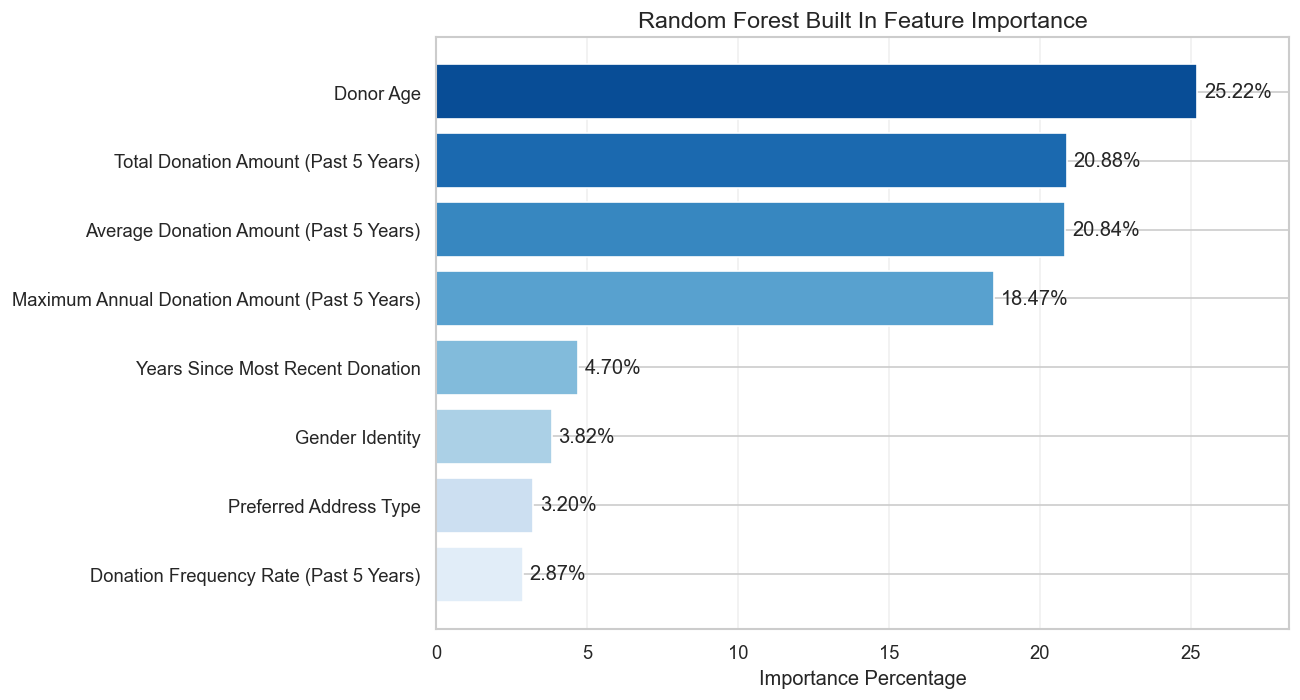

Importance Rank,Transformed Feature,Source Feature,Category Level,Business-Friendly Label,Built In Importance,Importance Percentage,Cumulative Importance Percentage
1,donor_age,donor_age,Not applicable,Donor Age,0.252192,25.22%,25.22%
2,feature_past_5yr_total_donation,feature_past_5yr_total_donation,Not applicable,Total Donation Amount (Past 5 Years),0.208825,20.88%,46.10%
3,feature_past_5yr_average_donation,feature_past_5yr_average_donation,Not applicable,Average Donation Amount (Past 5 Years),0.208400,20.84%,66.94%
4,feature_past_5yr_max_donation,feature_past_5yr_max_donation,Not applicable,Maximum Annual Donation Amount (Past 5 Years),0.184701,18.47%,85.41%
5,feature_years_since_last_donation_past_5yr,feature_years_since_last_donation_past_5yr,Not applicable,Years Since Most Recent Donation,0.046970,4.70%,90.11%
6,feature_past_5yr_donation_frequency_rate,feature_past_5yr_donation_frequency_rate,Not applicable,Donation Frequency Rate (Past 5 Years),0.028688,2.87%,92.98%
7,feature_gender_identity_Male,feature_gender_identity,Male,Gender Identity: Male,0.015680,1.57%,94.55%
8,feature_gender_identity_Female,feature_gender_identity,Female,Gender Identity: Female,0.014571,1.46%,96.00%
9,feature_preferred_address_type_Home,feature_preferred_address_type,Home Address,Preferred Address Type: Home Address,0.011995,1.20%,97.20%
10,feature_preferred_address_type_Missing,feature_preferred_address_type,Missing,Preferred Address Type: Missing,0.008809,0.88%,98.08%


Importance Rank,Source Feature,Business-Friendly Label,Representation,Transformed Columns,Built In Importance,Importance Percentage,Cumulative Importance Percentage
1,donor_age,Donor Age,Numeric,1,0.252192,25.22%,25.22%
2,feature_past_5yr_total_donation,Total Donation Amount (Past 5 Years),Numeric,1,0.208825,20.88%,46.10%
3,feature_past_5yr_average_donation,Average Donation Amount (Past 5 Years),Numeric,1,0.208400,20.84%,66.94%
4,feature_past_5yr_max_donation,Maximum Annual Donation Amount (Past 5 Years),Numeric,1,0.184701,18.47%,85.41%
5,feature_years_since_last_donation_past_5yr,Years Since Most Recent Donation,Numeric,1,0.046970,4.70%,90.11%
6,feature_gender_identity,Gender Identity,One-Hot Encoded,3,0.038187,3.82%,93.93%
7,feature_preferred_address_type,Preferred Address Type,One-Hot Encoded,5,0.032039,3.20%,97.13%
8,feature_past_5yr_donation_frequency_rate,Donation Frequency Rate (Past 5 Years),Numeric,1,0.028688,2.87%,100.00%


Random Forest importance ranking completed successfully: 13/13 checks passed.
Transformed importance saved to: outputs/interpretability/tables/primary_builtin_importance_transformed.csv
Source importance saved to: outputs/interpretability/tables/primary_builtin_importance_source.csv
Importance figure saved to: outputs/interpretability/figures/primary_builtin_importance_source.png


In [9]:
# Calculate random forest feature importance ranking
importance_values_primary_transformed = np.asarray(
    classifier_primary_saved.feature_importances_,
    dtype=float,
)

importance_primary_transformed = (
    mapping_primary_transformed_features.copy()
)

importance_primary_transformed[
    "Built In Importance"
] = importance_values_primary_transformed

importance_primary_transformed[
    "Importance Percentage"
] = (
    importance_primary_transformed[
        "Built In Importance"
    ]
    * 100
)

importance_primary_transformed = (
    importance_primary_transformed
    .sort_values(
        "Built In Importance",
        ascending=False,
        kind="stable",
    )
    .reset_index(drop=True)
)

importance_primary_transformed.insert(
    0,
    "Importance Rank",
    np.arange(
        1,
        importance_primary_transformed.shape[0] + 1,
    ),
)

importance_primary_transformed[
    "Cumulative Importance Percentage"
] = (
    importance_primary_transformed[
        "Importance Percentage"
    ].cumsum()
)

importance_primary_source_totals = (
    importance_primary_transformed
    .groupby(
        "Source Feature",
        as_index=False,
        sort=False,
    )
    .agg(
        **{
            "Built In Importance": (
                "Built In Importance",
                "sum",
            ),
            "Mapped Transformed Columns": (
                "Transformed Feature",
                "count",
            ),
        }
    )
)

importance_primary_source = (
    mapping_primary_source_features.merge(
        importance_primary_source_totals,
        on="Source Feature",
        how="left",
        validate="one_to_one",
    )
)

importance_primary_source[
    "Importance Percentage"
] = (
    importance_primary_source[
        "Built In Importance"
    ]
    * 100
)

importance_primary_source = (
    importance_primary_source
    .sort_values(
        "Built In Importance",
        ascending=False,
        kind="stable",
    )
    .reset_index(drop=True)
)

importance_primary_source.insert(
    0,
    "Importance Rank",
    np.arange(
        1,
        importance_primary_source.shape[0] + 1,
    ),
)

importance_primary_source[
    "Cumulative Importance Percentage"
] = (
    importance_primary_source[
        "Importance Percentage"
    ].cumsum()
)

PRIMARY_TRANSFORMED_IMPORTANCE_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_builtin_importance_transformed.csv"
)

PRIMARY_SOURCE_IMPORTANCE_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_builtin_importance_source.csv"
)

PRIMARY_SOURCE_IMPORTANCE_FIGURE_PATH = (
    INTERPRETABILITY_FIGURES_DIR
    / "primary_builtin_importance_source.png"
)

importance_primary_transformed.to_csv(
    PRIMARY_TRANSFORMED_IMPORTANCE_PATH,
    index=False,
)

importance_primary_source.to_csv(
    PRIMARY_SOURCE_IMPORTANCE_PATH,
    index=False,
)

importance_primary_source_plot = (
    importance_primary_source
    .sort_values(
        "Built In Importance",
        ascending=True,
    )
)

figure_primary_source_importance, axis_primary_source_importance = (
    plt.subplots(figsize=(11, 6))
)

bars_primary_source_importance = (
    axis_primary_source_importance.barh(
        importance_primary_source_plot[
            "Business-Friendly Label"
        ],
        importance_primary_source_plot[
            "Importance Percentage"
        ],
        color=sns.color_palette(
            "Blues",
            n_colors=importance_primary_source_plot.shape[0],
        ),
    )
)

axis_primary_source_importance.bar_label(
    bars_primary_source_importance,
    labels=[
        f"{importance_percentage:.2f}%"
        for importance_percentage
        in importance_primary_source_plot[
            "Importance Percentage"
        ]
    ],
    padding=4,
)

axis_primary_source_importance.set_title(
    "Random Forest Built In Feature Importance"
)
axis_primary_source_importance.set_xlabel(
    "Importance Percentage"
)
axis_primary_source_importance.set_ylabel("")
axis_primary_source_importance.grid(
    axis="x",
    alpha=0.30,
)
axis_primary_source_importance.margins(x=0.12)

plt.tight_layout()

figure_primary_source_importance.savefig(
    PRIMARY_SOURCE_IMPORTANCE_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

grouped_importance_validation = (
    importance_primary_transformed
    .groupby("Source Feature")[
        "Built In Importance"
    ]
    .sum()
    .sort_index()
)

saved_source_importance_validation = (
    importance_primary_source
    .set_index("Source Feature")[
        "Built In Importance"
    ]
    .sort_index()
)

importance_ranking_checks = {
    "Classifier is a fitted Random Forest": (
        type(classifier_primary_saved).__name__
        == "RandomForestClassifier"
        and hasattr(
            classifier_primary_saved,
            "feature_importances_",
        )
    ),
    "Importance count matches transformed features": (
        importance_values_primary_transformed.shape[0]
        == len(features_primary_transformed)
        == mapping_primary_transformed_features.shape[0]
    ),
    "Transformed feature order matches the classifier input": (
        mapping_primary_transformed_features[
            "Transformed Feature"
        ].tolist()
        == list(features_primary_transformed)
    ),
    "Transformed importance values are finite": (
        np.isfinite(
            importance_values_primary_transformed
        ).all()
    ),
    "Transformed importance values are nonnegative": (
        (
            importance_values_primary_transformed
            >= 0
        ).all()
    ),
    "Transformed importance values sum to one": (
        np.isclose(
            importance_values_primary_transformed.sum(),
            1.0,
            rtol=0,
            atol=1e-12,
        )
    ),
    "All eight source features are ranked": (
        importance_primary_source.shape[0]
        == len(features_primary_saved)
        == 8
    ),
    "Source importance reproduces transformed aggregation": (
        np.allclose(
            grouped_importance_validation.to_numpy(),
            saved_source_importance_validation.to_numpy(),
            rtol=0,
            atol=1e-12,
        )
    ),
    "Source importance values sum to one": (
        np.isclose(
            importance_primary_source[
                "Built In Importance"
            ].sum(),
            1.0,
            rtol=0,
            atol=1e-12,
        )
    ),
    "Transformed column counts remain consistent": (
        np.array_equal(
            importance_primary_source[
                "Transformed Columns"
            ].astype(int).to_numpy(),
            importance_primary_source[
                "Mapped Transformed Columns"
            ].astype(int).to_numpy(),
        )
    ),
    "Transformed importance ranks are complete": (
        np.array_equal(
            importance_primary_transformed[
                "Importance Rank"
            ].to_numpy(),
            np.arange(
                1,
                importance_primary_transformed.shape[0] + 1,
            ),
        )
    ),
    "Source importance ranks are complete": (
        np.array_equal(
            importance_primary_source[
                "Importance Rank"
            ].to_numpy(),
            np.arange(
                1,
                importance_primary_source.shape[0] + 1,
            ),
        )
    ),
    "Importance artifacts were saved": (
        PRIMARY_TRANSFORMED_IMPORTANCE_PATH.exists()
        and PRIMARY_SOURCE_IMPORTANCE_PATH.exists()
        and PRIMARY_SOURCE_IMPORTANCE_FIGURE_PATH.exists()
    ),
}

failed_importance_ranking_checks = [
    check_name
    for check_name, check_passed
    in importance_ranking_checks.items()
    if not check_passed
]

if failed_importance_ranking_checks:
    raise AssertionError(
        "Built in importance validation failed for: "
        + ", ".join(failed_importance_ranking_checks)
    )

display(
    importance_primary_transformed[
        [
            "Importance Rank",
            "Transformed Feature",
            "Source Feature",
            "Category Level",
            "Business-Friendly Label",
            "Built In Importance",
            "Importance Percentage",
            "Cumulative Importance Percentage",
        ]
    ].style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Importance Rank": "{:,.0f}",
            "Transformed Feature": "{}",
            "Source Feature": "{}",
            "Category Level": "{}",
            "Business-Friendly Label": "{}",
            "Built In Importance": "{:,.6f}",
            "Importance Percentage": "{:,.2f}%",
            "Cumulative Importance Percentage": "{:,.2f}%",
        }
    )
)

display(
    importance_primary_source[
        [
            "Importance Rank",
            "Source Feature",
            "Business-Friendly Label",
            "Representation",
            "Transformed Columns",
            "Built In Importance",
            "Importance Percentage",
            "Cumulative Importance Percentage",
        ]
    ].style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Importance Rank": "{:,.0f}",
            "Source Feature": "{}",
            "Business-Friendly Label": "{}",
            "Representation": "{}",
            "Transformed Columns": "{:,.0f}",
            "Built In Importance": "{:,.6f}",
            "Importance Percentage": "{:,.2f}%",
            "Cumulative Importance Percentage": "{:,.2f}%",
        }
    )
)

print(
    "Random Forest importance ranking completed successfully: "
    f"{sum(importance_ranking_checks.values())}/"
    f"{len(importance_ranking_checks)} checks passed."
)
print(
    "Transformed importance saved to: "
    f"{PRIMARY_TRANSFORMED_IMPORTANCE_PATH.relative_to(PROJECT_ROOT)}"
)
print(
    "Source importance saved to: "
    f"{PRIMARY_SOURCE_IMPORTANCE_PATH.relative_to(PROJECT_ROOT)}"
)
print(
    "Importance figure saved to: "
    f"{PRIMARY_SOURCE_IMPORTANCE_FIGURE_PATH.relative_to(PROJECT_ROOT)}"
)

## Interpretation Framework and Initial Feature Importance

The interpretation framework was defined to organize the analysis into six areas: global explanations, local explanations, outreach cohort analysis, error analysis, stability testing, and fairness review. Each area was assigned a clear purpose, evaluation dataset, planned method, reporting level, and safeguard. The finalized Phase 5 model, primary target, operating threshold, selection metric, and outreach capacities remain unchanged. Model scores will be treated as donor ranking scores rather than literal donation probabilities, and interpretation results will not be treated as causal relationships.

The Random Forest importance calculation was completed for all 14 transformed features and summarized across the eight original source features. Importance from the encoded gender identity and preferred address type columns was combined to provide one source level value for each predictor. All 13 importance validation checks passed, and the transformed ranking, source ranking, and source importance figure were saved as interpretation artifacts.

### Initial Importance Ranking

- Donor age ranked first with 25.22% of total importance.
- Total donation amount, average donation amount, and maximum annual donation amount followed with 20.88%, 20.84%, and 18.47%, respectively.
- Donor age and the three donation amount features account for 85.41% of total importance.
- The five historical donation features account for 67.76% of total importance when donation amount, recency, and frequency measures are combined.
- Gender identity contributes 3.82%, preferred address type contributes 3.20%, and donation frequency rate contributes 2.87%.

These results provide an initial view of how the Random Forest used its predictors when creating decision splits. They do not show whether a feature increases or decreases a donor score. Donor age may receive additional importance because it provides many possible split values, while related donation amount features may divide importance among themselves. Permutation importance and SHAP analysis will be used to determine whether these patterns remain consistent across other interpretation methods.


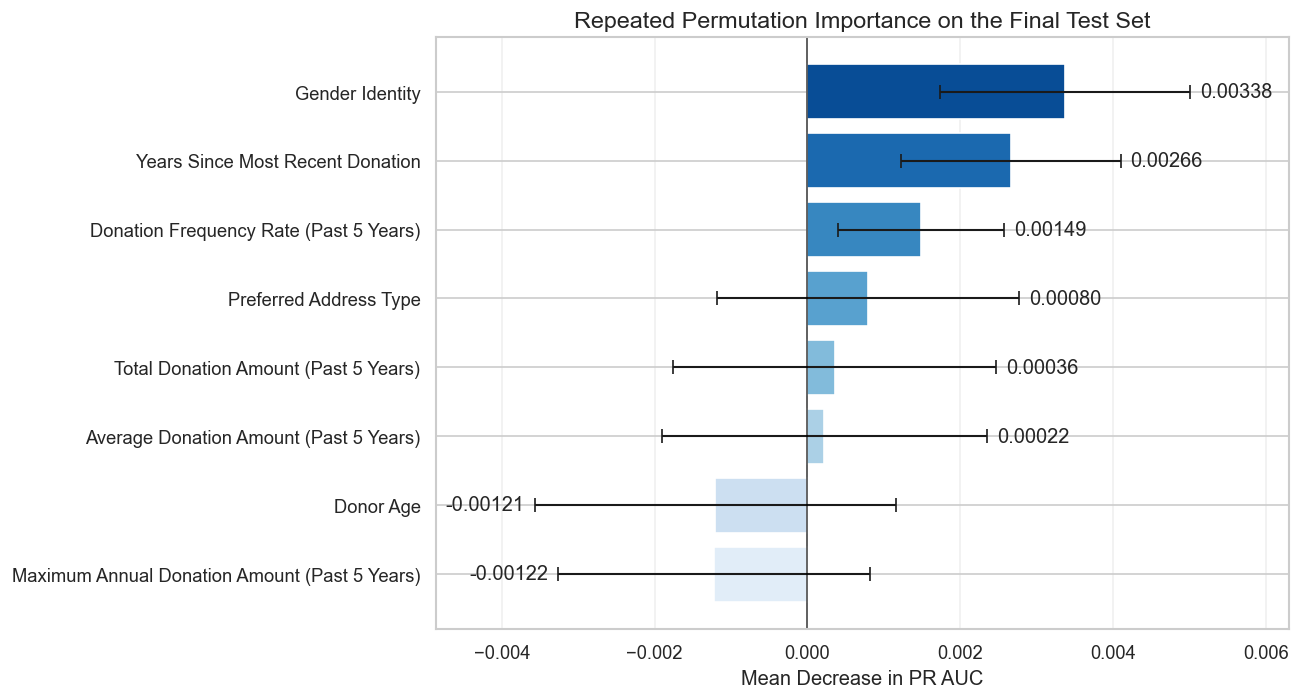

Permutation Rank,Source Feature,Business-Friendly Label,Mean PR AUC Decrease,Standard Deviation,Median PR AUC Decrease,Lower Percentile (2.5%),Upper Percentile (97.5%),Positive Repeat Percentage,Mean Permuted PR AUC
1,feature_gender_identity,Gender Identity,0.003378,0.001636,0.003321,0.000637,0.006649,96.67%,0.067013
2,feature_years_since_last_donation_past_5yr,Years Since Most Recent Donation,0.002660,0.001440,0.002659,0.000205,0.005305,100.00%,0.067732
3,feature_past_5yr_donation_frequency_rate,Donation Frequency Rate (Past 5 Years),0.001486,0.001087,0.001544,-0.000603,0.003370,90.00%,0.068905
4,feature_preferred_address_type,Preferred Address Type,0.000797,0.001975,0.000477,-0.003205,0.004398,70.00%,0.069595
5,feature_past_5yr_total_donation,Total Donation Amount (Past 5 Years),0.000356,0.002113,0.000585,-0.003550,0.003964,60.00%,0.070035
6,feature_past_5yr_average_donation,Average Donation Amount (Past 5 Years),0.000221,0.002129,0.000804,-0.003613,0.003719,56.67%,0.070171
7,donor_age,Donor Age,-0.001206,0.002365,-0.001107,-0.005955,0.002475,33.33%,0.071598
8,feature_past_5yr_max_donation,Maximum Annual Donation Amount (Past 5 Years),-0.001223,0.002041,-0.001283,-0.005063,0.002596,30.00%,0.071615


Baseline final test PR AUC: 0.070392
Repeated permutation importance completed successfully: 17/17 checks passed.
Permutation repeats saved to: outputs/interpretability/tables/primary_permutation_importance_repeats.csv
Permutation summary saved to: outputs/interpretability/tables/primary_permutation_importance_summary.csv
Permutation figure saved to: outputs/interpretability/figures/primary_permutation_importance_pr_auc.png


In [10]:
# Calculate repeated permutation importance on final test set
baseline_pr_auc_primary_saved = average_precision_score(
    target_primary_test_interpretation,
    data_primary_test_interpretation[
        "prob_primary_donor"
    ].astype(float),
)

baseline_pr_auc_primary_pipeline = average_precision_score(
    target_primary_test_interpretation,
    probabilities_primary_test_recalculated,
)

permutation_result_primary = permutation_importance(
    estimator=model_primary_pipeline_final,
    X=features_primary_test_interpretation,
    y=target_primary_test_interpretation,
    scoring=INTERPRETATION_PRIMARY_METRIC,
    n_repeats=PERMUTATION_IMPORTANCE_REPEATS,
    random_state=RANDOM_STATE,
    n_jobs=PERMUTATION_IMPORTANCE_N_JOBS,
)

source_business_label_lookup = (
    mapping_primary_source_features
    .set_index("Source Feature")[
        "Business-Friendly Label"
    ]
    .to_dict()
)

permutation_repeat_records = []

for source_position, source_feature_name in enumerate(
    features_primary_saved,
    start=1,
):
    feature_repeat_decreases = (
        permutation_result_primary.importances[
            source_position - 1
        ]
    )

    for repeat_number, pr_auc_decrease in enumerate(
        feature_repeat_decreases,
        start=1,
    ):
        permutation_repeat_records.append(
            {
                "Source Position": source_position,
                "Source Feature": source_feature_name,
                "Business-Friendly Label": (
                    source_business_label_lookup[
                        source_feature_name
                    ]
                ),
                "Repeat Number": repeat_number,
                "Baseline PR AUC": (
                    baseline_pr_auc_primary_pipeline
                ),
                "Permuted PR AUC": (
                    baseline_pr_auc_primary_pipeline
                    - pr_auc_decrease
                ),
                "PR AUC Decrease": pr_auc_decrease,
            }
        )

importance_primary_permutation_repeats = pd.DataFrame(
    permutation_repeat_records
)

permutation_summary_records = []

for source_position, source_feature_name in enumerate(
    features_primary_saved,
    start=1,
):
    feature_repeat_decreases = (
        permutation_result_primary.importances[
            source_position - 1
        ]
    )

    permutation_summary_records.append(
        {
            "Source Position": source_position,
            "Source Feature": source_feature_name,
            "Business-Friendly Label": (
                source_business_label_lookup[
                    source_feature_name
                ]
            ),
            "Baseline PR AUC": (
                baseline_pr_auc_primary_pipeline
            ),
            "Mean PR AUC Decrease": float(
                feature_repeat_decreases.mean()
            ),
            "Standard Deviation": float(
                feature_repeat_decreases.std(ddof=0)
            ),
            "Median PR AUC Decrease": float(
                np.median(feature_repeat_decreases)
            ),
            "Lower Percentile (2.5%)": float(
                np.quantile(
                    feature_repeat_decreases,
                    0.025,
                )
            ),
            "Upper Percentile (97.5%)": float(
                np.quantile(
                    feature_repeat_decreases,
                    0.975,
                )
            ),
            "Minimum PR AUC Decrease": float(
                feature_repeat_decreases.min()
            ),
            "Maximum PR AUC Decrease": float(
                feature_repeat_decreases.max()
            ),
            "Positive Repeat Percentage": float(
                (
                    feature_repeat_decreases > 0
                ).mean()
                * 100
            ),
            "Mean Permuted PR AUC": float(
                baseline_pr_auc_primary_pipeline
                - feature_repeat_decreases.mean()
            ),
        }
    )

importance_primary_permutation = pd.DataFrame(
    permutation_summary_records
)

importance_primary_permutation = (
    importance_primary_permutation
    .sort_values(
        "Mean PR AUC Decrease",
        ascending=False,
        kind="stable",
    )
    .reset_index(drop=True)
)

importance_primary_permutation.insert(
    0,
    "Permutation Rank",
    np.arange(
        1,
        importance_primary_permutation.shape[0] + 1,
    ),
)

PRIMARY_PERMUTATION_REPEATS_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_permutation_importance_repeats.csv"
)

PRIMARY_PERMUTATION_SUMMARY_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_permutation_importance_summary.csv"
)

PRIMARY_PERMUTATION_FIGURE_PATH = (
    INTERPRETABILITY_FIGURES_DIR
    / "primary_permutation_importance_pr_auc.png"
)

importance_primary_permutation_repeats.to_csv(
    PRIMARY_PERMUTATION_REPEATS_PATH,
    index=False,
)

importance_primary_permutation.to_csv(
    PRIMARY_PERMUTATION_SUMMARY_PATH,
    index=False,
)

importance_primary_permutation_plot = (
    importance_primary_permutation
    .sort_values(
        "Mean PR AUC Decrease",
        ascending=True,
    )
)

figure_primary_permutation, axis_primary_permutation = (
    plt.subplots(figsize=(11, 6))
)

bars_primary_permutation = axis_primary_permutation.barh(
    importance_primary_permutation_plot[
        "Business-Friendly Label"
    ],
    importance_primary_permutation_plot[
        "Mean PR AUC Decrease"
    ],
    xerr=importance_primary_permutation_plot[
        "Standard Deviation"
    ],
    color=sns.color_palette(
        "Blues",
        n_colors=importance_primary_permutation_plot.shape[0],
    ),
    error_kw={
        "elinewidth": 1.25,
        "capsize": 4,
    },
)

axis_primary_permutation.bar_label(
    bars_primary_permutation,
    labels=[
        f"{mean_decrease:.5f}"
        for mean_decrease
        in importance_primary_permutation_plot[
            "Mean PR AUC Decrease"
        ]
    ],
    padding=6,
)

axis_primary_permutation.axvline(
    0,
    color="black",
    linewidth=1,
    alpha=0.70,
)

axis_primary_permutation.set_title(
    "Repeated Permutation Importance on the Final Test Set"
)
axis_primary_permutation.set_xlabel(
    "Mean Decrease in PR AUC"
)
axis_primary_permutation.set_ylabel("")
axis_primary_permutation.grid(
    axis="x",
    alpha=0.30,
)
axis_primary_permutation.margins(x=0.15)

plt.tight_layout()

figure_primary_permutation.savefig(
    PRIMARY_PERMUTATION_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

permutation_summary_source_order = (
    importance_primary_permutation
    .set_index("Source Feature")
    .loc[features_primary_saved]
)

repeat_counts_by_feature = (
    importance_primary_permutation_repeats
    .groupby("Source Feature")
    .size()
)

probabilities_primary_after_permutation = (
    model_primary_pipeline_final.predict_proba(
        features_primary_test_interpretation
    )[:, positive_class_index]
)

permutation_importance_checks = {
    "Permutation metric is average precision": (
        INTERPRETATION_PRIMARY_METRIC
        == "average_precision"
    ),
    "Final test source feature order is preserved": (
        list(
            features_primary_test_interpretation.columns
        )
        == list(features_primary_saved)
    ),
    "Saved and pipeline baseline PR AUC values match": (
        np.isclose(
            baseline_pr_auc_primary_saved,
            baseline_pr_auc_primary_pipeline,
            rtol=1e-10,
            atol=1e-12,
        )
    ),
    "Baseline PR AUC uses aligned final test records": (
        target_primary_test_interpretation.shape[0]
        == expected_primary_decisions[
            "final_test_records"
        ]
        == features_primary_test_interpretation.shape[0]
    ),
    "Permutation repeat count is valid": (
        isinstance(
            PERMUTATION_IMPORTANCE_REPEATS,
            int,
        )
        and PERMUTATION_IMPORTANCE_REPEATS > 1
    ),
    "Permutation result shape is correct": (
        permutation_result_primary.importances.shape
        == (
            len(features_primary_saved),
            PERMUTATION_IMPORTANCE_REPEATS,
        )
    ),
    "Permutation values are finite": (
        np.isfinite(
            permutation_result_primary.importances
        ).all()
    ),
    "Repeat table has the expected record count": (
        importance_primary_permutation_repeats.shape[0]
        == (
            len(features_primary_saved)
            * PERMUTATION_IMPORTANCE_REPEATS
        )
    ),
    "Every source feature has all repetitions": (
        repeat_counts_by_feature.eq(
            PERMUTATION_IMPORTANCE_REPEATS
        ).all()
        and repeat_counts_by_feature.shape[0]
        == len(features_primary_saved)
    ),
    "All eight source features are summarized": (
        importance_primary_permutation.shape[0]
        == len(features_primary_saved)
        == 8
    ),
    "Summary means reproduce the permutation result": (
        np.allclose(
            permutation_summary_source_order[
                "Mean PR AUC Decrease"
            ].to_numpy(),
            permutation_result_primary.importances_mean,
            rtol=0,
            atol=1e-12,
        )
    ),
    "Summary deviations reproduce the permutation result": (
        np.allclose(
            permutation_summary_source_order[
                "Standard Deviation"
            ].to_numpy(),
            permutation_result_primary.importances_std,
            rtol=0,
            atol=1e-12,
        )
    ),
    "Percentile ranges are ordered correctly": (
        (
            importance_primary_permutation[
                "Lower Percentile (2.5%)"
            ]
            <= importance_primary_permutation[
                "Median PR AUC Decrease"
            ]
        ).all()
        and (
            importance_primary_permutation[
                "Median PR AUC Decrease"
            ]
            <= importance_primary_permutation[
                "Upper Percentile (97.5%)"
            ]
        ).all()
    ),
    "All source features have business labels": (
        importance_primary_permutation[
            "Business-Friendly Label"
        ].notna().all()
        and importance_primary_permutation[
            "Business-Friendly Label"
        ].is_unique
    ),
    "Permutation ranking is descending": (
        importance_primary_permutation[
            "Mean PR AUC Decrease"
        ].is_monotonic_decreasing
        and np.array_equal(
            importance_primary_permutation[
                "Permutation Rank"
            ].to_numpy(),
            np.arange(
                1,
                importance_primary_permutation.shape[0] + 1,
            ),
        )
    ),
    "Permutation did not modify model predictions": (
        np.allclose(
            probabilities_primary_after_permutation,
            probabilities_primary_test_recalculated,
            rtol=1e-10,
            atol=1e-12,
        )
    ),
    "Permutation artifacts were saved": (
        PRIMARY_PERMUTATION_REPEATS_PATH.exists()
        and PRIMARY_PERMUTATION_SUMMARY_PATH.exists()
        and PRIMARY_PERMUTATION_FIGURE_PATH.exists()
    ),
}

failed_permutation_importance_checks = [
    check_name
    for check_name, check_passed
    in permutation_importance_checks.items()
    if not check_passed
]

if failed_permutation_importance_checks:
    raise AssertionError(
        "Permutation importance validation failed for: "
        + ", ".join(
            failed_permutation_importance_checks
        )
    )

display(
    importance_primary_permutation[
        [
            "Permutation Rank",
            "Source Feature",
            "Business-Friendly Label",
            "Mean PR AUC Decrease",
            "Standard Deviation",
            "Median PR AUC Decrease",
            "Lower Percentile (2.5%)",
            "Upper Percentile (97.5%)",
            "Positive Repeat Percentage",
            "Mean Permuted PR AUC",
        ]
    ].style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Permutation Rank": "{:,.0f}",
            "Source Feature": "{}",
            "Business-Friendly Label": "{}",
            "Mean PR AUC Decrease": "{:,.6f}",
            "Standard Deviation": "{:,.6f}",
            "Median PR AUC Decrease": "{:,.6f}",
            "Lower Percentile (2.5%)": "{:,.6f}",
            "Upper Percentile (97.5%)": "{:,.6f}",
            "Positive Repeat Percentage": "{:,.2f}%",
            "Mean Permuted PR AUC": "{:,.6f}",
        }
    )
)

print(
    "Baseline final test PR AUC: "
    f"{baseline_pr_auc_primary_pipeline:.6f}"
)
print(
    "Repeated permutation importance completed successfully: "
    f"{sum(permutation_importance_checks.values())}/"
    f"{len(permutation_importance_checks)} checks passed."
)
print(
    "Permutation repeats saved to: "
    f"{PRIMARY_PERMUTATION_REPEATS_PATH.relative_to(PROJECT_ROOT)}"
)
print(
    "Permutation summary saved to: "
    f"{PRIMARY_PERMUTATION_SUMMARY_PATH.relative_to(PROJECT_ROOT)}"
)
print(
    "Permutation figure saved to: "
    f"{PRIMARY_PERMUTATION_FIGURE_PATH.relative_to(PROJECT_ROOT)}"
)

In [11]:
# Configure SHAP and validate model output reconstruction
SHAP_FEATURE_PERTURBATION = "tree_path_dependent"
SHAP_MODEL_OUTPUT = "raw"
SHAP_ADDITIVITY_TOLERANCE = 1e-8

if hasattr(
    features_primary_test_transformed,
    "toarray",
):
    features_primary_test_shap_array = (
        features_primary_test_transformed.toarray()
    )
else:
    features_primary_test_shap_array = np.asarray(
        features_primary_test_transformed
    )

features_primary_test_shap_array = np.asarray(
    features_primary_test_shap_array,
    dtype=float,
)

shap_test_record_count = (
    features_primary_test_shap_array.shape[0]
)
shap_transformed_feature_count = (
    features_primary_test_shap_array.shape[1]
)

classes_primary_shap = np.asarray(
    classifier_primary_saved.classes_
)

positive_class_index_shap = int(
    np.flatnonzero(
        classes_primary_shap == 1
    )[0]
)

explainer_primary_shap = shap.TreeExplainer(
    classifier_primary_saved,
    feature_perturbation=SHAP_FEATURE_PERTURBATION,
    model_output=SHAP_MODEL_OUTPUT,
)

explanation_primary_shap_raw = (
    explainer_primary_shap(
        features_primary_test_shap_array,
        check_additivity=False,
    )
)

shap_values_primary_raw = np.asarray(
    explanation_primary_shap_raw.values
)

shap_base_values_primary_raw = np.asarray(
    explanation_primary_shap_raw.base_values
)

if (
    shap_values_primary_raw.ndim == 3
    and shap_values_primary_raw.shape
    == (
        shap_test_record_count,
        shap_transformed_feature_count,
        classes_primary_shap.size,
    )
):
    shap_values_primary_positive = (
        shap_values_primary_raw[
            :,
            :,
            positive_class_index_shap,
        ]
    )
    shap_value_layout_primary = (
        "Records by features by classes"
    )

elif (
    shap_values_primary_raw.ndim == 3
    and shap_values_primary_raw.shape
    == (
        classes_primary_shap.size,
        shap_test_record_count,
        shap_transformed_feature_count,
    )
):
    shap_values_primary_positive = (
        shap_values_primary_raw[
            positive_class_index_shap,
            :,
            :,
        ]
    )
    shap_value_layout_primary = (
        "Classes by records by features"
    )

elif (
    shap_values_primary_raw.ndim == 2
    and shap_values_primary_raw.shape
    == (
        shap_test_record_count,
        shap_transformed_feature_count,
    )
):
    shap_values_primary_positive = (
        shap_values_primary_raw.copy()
    )
    shap_value_layout_primary = (
        "Records by features"
    )

else:
    raise ValueError(
        "Unsupported SHAP value shape: "
        f"{shap_values_primary_raw.shape}"
    )

if shap_base_values_primary_raw.ndim == 0:
    shap_base_values_primary_positive = np.full(
        shap_test_record_count,
        float(shap_base_values_primary_raw),
    )

elif (
    shap_base_values_primary_raw.ndim == 1
    and shap_base_values_primary_raw.size
    == classes_primary_shap.size
):
    shap_base_values_primary_positive = np.full(
        shap_test_record_count,
        float(
            shap_base_values_primary_raw[
                positive_class_index_shap
            ]
        ),
    )

elif (
    shap_base_values_primary_raw.ndim == 1
    and shap_base_values_primary_raw.size
    == shap_test_record_count
):
    shap_base_values_primary_positive = (
        shap_base_values_primary_raw.astype(float)
    )

elif (
    shap_base_values_primary_raw.ndim == 2
    and shap_base_values_primary_raw.shape
    == (
        shap_test_record_count,
        classes_primary_shap.size,
    )
):
    shap_base_values_primary_positive = (
        shap_base_values_primary_raw[
            :,
            positive_class_index_shap,
        ].astype(float)
    )

elif (
    shap_base_values_primary_raw.ndim == 2
    and shap_base_values_primary_raw.shape
    == (
        classes_primary_shap.size,
        shap_test_record_count,
    )
):
    shap_base_values_primary_positive = (
        shap_base_values_primary_raw[
            positive_class_index_shap,
            :,
        ].astype(float)
    )

elif (
    shap_base_values_primary_raw.ndim == 2
    and shap_base_values_primary_raw.shape
    == (
        shap_test_record_count,
        1,
    )
):
    shap_base_values_primary_positive = (
        shap_base_values_primary_raw[
            :,
            0,
        ].astype(float)
    )

else:
    raise ValueError(
        "Unsupported SHAP base value shape: "
        f"{shap_base_values_primary_raw.shape}"
    )

probabilities_primary_classifier_shap = (
    classifier_primary_saved.predict_proba(
        features_primary_test_shap_array
    )[:, positive_class_index_shap]
)

probabilities_primary_pipeline_shap = (
    model_primary_pipeline_final.predict_proba(
        features_primary_test_interpretation
    )[:, positive_class_index_shap]
)

probabilities_primary_reconstructed_shap = (
    shap_base_values_primary_positive
    + shap_values_primary_positive.sum(axis=1)
)

errors_primary_shap_additivity = (
    probabilities_primary_reconstructed_shap
    - probabilities_primary_classifier_shap
)

absolute_errors_primary_shap_additivity = np.abs(
    errors_primary_shap_additivity
)

mean_absolute_error_primary_shap = float(
    absolute_errors_primary_shap_additivity.mean()
)

maximum_absolute_error_primary_shap = float(
    absolute_errors_primary_shap_additivity.max()
)

shap_additivity_passed = np.allclose(
    probabilities_primary_reconstructed_shap,
    probabilities_primary_classifier_shap,
    rtol=SHAP_ADDITIVITY_TOLERANCE,
    atol=SHAP_ADDITIVITY_TOLERANCE,
)

explanation_primary_shap = shap.Explanation(
    values=shap_values_primary_positive,
    base_values=shap_base_values_primary_positive,
    data=features_primary_test_shap_array,
    feature_names=list(
        features_primary_transformed
    ),
)

shap_value_column_names = [
    f"shap_value__{transformed_feature_name}"
    for transformed_feature_name
    in features_primary_transformed
]

values_primary_shap_final_test = pd.DataFrame(
    shap_values_primary_positive,
    columns=shap_value_column_names,
)

values_primary_shap_final_test.insert(
    0,
    "test_record_position",
    np.arange(
        1,
        shap_test_record_count + 1,
    ),
)

values_primary_shap_final_test.insert(
    1,
    "target_actual_primary_donor_flag",
    target_primary_test_interpretation
    .astype(int)
    .to_numpy(),
)

values_primary_shap_final_test.insert(
    2,
    "prob_primary_donor",
    probabilities_primary_classifier_shap,
)

values_primary_shap_final_test.insert(
    3,
    "shap_base_value_primary_donor",
    shap_base_values_primary_positive,
)

values_primary_shap_final_test.insert(
    4,
    "shap_reconstructed_prob_primary_donor",
    probabilities_primary_reconstructed_shap,
)

values_primary_shap_final_test.insert(
    5,
    "shap_additivity_absolute_error",
    absolute_errors_primary_shap_additivity,
)

configuration_primary_shap = pd.DataFrame(
    [
        {
            "Explainer": "TreeExplainer",
            "Feature Perturbation": (
                SHAP_FEATURE_PERTURBATION
            ),
            "Explained Output": (
                "Positive class probability"
            ),
            "Records": shap_test_record_count,
            "Transformed Features": (
                shap_transformed_feature_count
            ),
            "Positive Class": int(
                classes_primary_shap[
                    positive_class_index_shap
                ]
            ),
            "Raw SHAP Shape": str(
                shap_values_primary_raw.shape
            ),
            "Raw SHAP Layout": (
                shap_value_layout_primary
            ),
            "Mean Base Value": float(
                shap_base_values_primary_positive.mean()
            ),
            "Mean Model Output": float(
                probabilities_primary_classifier_shap.mean()
            ),
            "Mean Reconstructed Output": float(
                probabilities_primary_reconstructed_shap.mean()
            ),
            "Mean Absolute Error": (
                mean_absolute_error_primary_shap
            ),
            "Maximum Absolute Error": (
                maximum_absolute_error_primary_shap
            ),
            "Additivity Tolerance": (
                SHAP_ADDITIVITY_TOLERANCE
            ),
            "Status": (
                "PASS"
                if shap_additivity_passed
                else "FAIL"
            ),
        }
    ]
)

PRIMARY_SHAP_CONFIGURATION_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_shap_configuration.csv"
)

PRIMARY_SHAP_VALUES_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_shap_values_final_test.csv"
)

configuration_primary_shap.to_csv(
    PRIMARY_SHAP_CONFIGURATION_PATH,
    index=False,
)

values_primary_shap_final_test.to_csv(
    PRIMARY_SHAP_VALUES_PATH,
    index=False,
)

shap_configuration_checks = {
    "Explainer uses the finalized Random Forest": (
        type(classifier_primary_saved).__name__
        == "RandomForestClassifier"
        and explainer_primary_shap.model is not None
    ),
    "SHAP input contains all final test records": (
        shap_test_record_count
        == expected_primary_decisions[
            "final_test_records"
        ]
        == features_primary_test_interpretation.shape[0]
    ),
    "SHAP input contains all transformed features": (
        shap_transformed_feature_count
        == expected_primary_decisions[
            "transformed_feature_count"
        ]
        == len(features_primary_transformed)
    ),
    "Transformed feature order is preserved": (
        mapping_primary_transformed_features[
            "Transformed Feature"
        ].tolist()
        == list(features_primary_transformed)
    ),
    "Positive class index is correct": (
        classes_primary_shap[
            positive_class_index_shap
        ]
        == 1
        and positive_class_index_shap
        == positive_class_index
    ),
    "Positive class SHAP matrix shape is correct": (
        shap_values_primary_positive.shape
        == (
            shap_test_record_count,
            shap_transformed_feature_count,
        )
    ),
    "Positive class base value shape is correct": (
        shap_base_values_primary_positive.shape
        == (shap_test_record_count,)
    ),
    "SHAP values and base values are finite": (
        np.isfinite(
            shap_values_primary_positive
        ).all()
        and np.isfinite(
            shap_base_values_primary_positive
        ).all()
    ),
    "Classifier and pipeline outputs match": (
        np.allclose(
            probabilities_primary_classifier_shap,
            probabilities_primary_pipeline_shap,
            rtol=1e-10,
            atol=1e-12,
        )
    ),
    "SHAP model outputs match saved probabilities": (
        np.allclose(
            probabilities_primary_classifier_shap,
            data_primary_test_interpretation[
                "prob_primary_donor"
            ].astype(float),
            rtol=1e-10,
            atol=1e-12,
        )
    ),
    "SHAP reconstruction matches model outputs": (
        shap_additivity_passed
    ),
    "Maximum additivity error is within tolerance": (
        maximum_absolute_error_primary_shap
        <= SHAP_ADDITIVITY_TOLERANCE
    ),
    "Reconstructed outputs remain valid probabilities": (
        (
            probabilities_primary_reconstructed_shap
            >= -SHAP_ADDITIVITY_TOLERANCE
        ).all()
        and (
            probabilities_primary_reconstructed_shap
            <= 1 + SHAP_ADDITIVITY_TOLERANCE
        ).all()
    ),
    "SHAP Explanation object is aligned": (
        explanation_primary_shap.values.shape
        == (
            shap_test_record_count,
            shap_transformed_feature_count,
        )
        and list(
            explanation_primary_shap.feature_names
        )
        == list(features_primary_transformed)
    ),
    "Saved SHAP table preserves test row order": (
        np.array_equal(
            values_primary_shap_final_test[
                "test_record_position"
            ].to_numpy(),
            np.arange(
                1,
                shap_test_record_count + 1,
            ),
        )
        and np.array_equal(
            values_primary_shap_final_test[
                "target_actual_primary_donor_flag"
            ].to_numpy(),
            target_primary_test_interpretation
            .astype(int)
            .to_numpy(),
        )
    ),
    "Saved SHAP table excludes donor identifiers": (
        "donor_unique_id"
        not in values_primary_shap_final_test.columns
    ),
    "SHAP configuration reports PASS": (
        configuration_primary_shap.loc[
            0,
            "Status",
        ]
        == "PASS"
    ),
    "SHAP artifacts were saved": (
        PRIMARY_SHAP_CONFIGURATION_PATH.exists()
        and PRIMARY_SHAP_VALUES_PATH.exists()
    ),
}

failed_shap_configuration_checks = [
    check_name
    for check_name, check_passed
    in shap_configuration_checks.items()
    if not check_passed
]

if failed_shap_configuration_checks:
    raise AssertionError(
        "SHAP configuration validation failed for: "
        + ", ".join(
            failed_shap_configuration_checks
        )
    )

display(
    configuration_primary_shap.style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Explainer": "{}",
            "Feature Perturbation": "{}",
            "Explained Output": "{}",
            "Records": "{:,.0f}",
            "Transformed Features": "{:,.0f}",
            "Positive Class": "{:,.0f}",
            "Raw SHAP Shape": "{}",
            "Raw SHAP Layout": "{}",
            "Mean Base Value": "{:,.8f}",
            "Mean Model Output": "{:,.8f}",
            "Mean Reconstructed Output": "{:,.8f}",
            "Mean Absolute Error": "{:,.2e}",
            "Maximum Absolute Error": "{:,.2e}",
            "Additivity Tolerance": "{:,.2e}",
            "Status": "{}",
        }
    )
)

print(
    "SHAP configuration and additivity validation completed: "
    f"{sum(shap_configuration_checks.values())}/"
    f"{len(shap_configuration_checks)} checks passed."
)
print(
    "SHAP configuration saved to: "
    f"{PRIMARY_SHAP_CONFIGURATION_PATH.relative_to(PROJECT_ROOT)}"
)
print(
    "Final test SHAP values saved to: "
    f"{PRIMARY_SHAP_VALUES_PATH.relative_to(PROJECT_ROOT)}"
)

Explainer,Feature Perturbation,Explained Output,Records,Transformed Features,Positive Class,Raw SHAP Shape,Raw SHAP Layout,Mean Base Value,Mean Model Output,Mean Reconstructed Output,Mean Absolute Error,Maximum Absolute Error,Additivity Tolerance,Status
TreeExplainer,tree_path_dependent,Positive class probability,"6,881",14,1,"(6881, 14, 2)",Records by features by classes,0.05528196,0.05514503,0.05514503,1.14e-16,3.89e-15,1.00e-08,PASS


SHAP configuration and additivity validation completed: 18/18 checks passed.
SHAP configuration saved to: outputs/interpretability/tables/primary_shap_configuration.csv
Final test SHAP values saved to: outputs/interpretability/tables/primary_shap_values_final_test.csv


## Permutation Importance and SHAP Validation
Repeated permutation importance was calculated on the final test set using average precision. Each source feature was shuffled 30 times while the remaining features were unchanged. The baseline PR AUC was 0.0704, and a larger positive decrease indicates a greater effect on predictive performance.

### Permutation Importance Findings
- Gender identity ranked first with a mean PR AUC decrease of 0.0034 and was positive in 96.67% of repetitions.
- Years since the most recent donation ranked second with a mean decrease of 0.0027 and was positive in all repetitions.
- Donation frequency rate ranked third with a mean decrease of 0.0015 and was positive in 90.00% of repetitions.
- Preferred address type and the donation amount features produced small or inconsistent effects.
- Donor age and maximum annual donation amount produced slightly negative average decreases.

Only gender identity and years since the most recent donation had percentile ranges entirely above zero. The remaining effects are less certain because their ranges crossed zero. Related donation amount features may also compensate for one another when an individual feature is shuffled, explaining their lower permutation importance compared with the Random Forest ranking.

### SHAP Configuration and Validation

TreeSHAP was configured for the finalized Random Forest using all 6,881 final test records and 14 transformed features. The base value and SHAP feature contributions were validated against the model output for every donor.
- The mean model output and reconstructed output both equal 0.0551.
- The mean absolute reconstruction error was $1.14 \times 10^{-16}$.
- The maximum reconstruction error was $3.89 \times 10^{-15}$, below the $1.00 \times 10^{-8}$ tolerance.

All 18 SHAP checks passed, confirming that the SHAP values accurately reproduce the Random Forest outputs. The configuration and final test SHAP values were saved for the global and local explanation analyses without exposing donor identifiers.


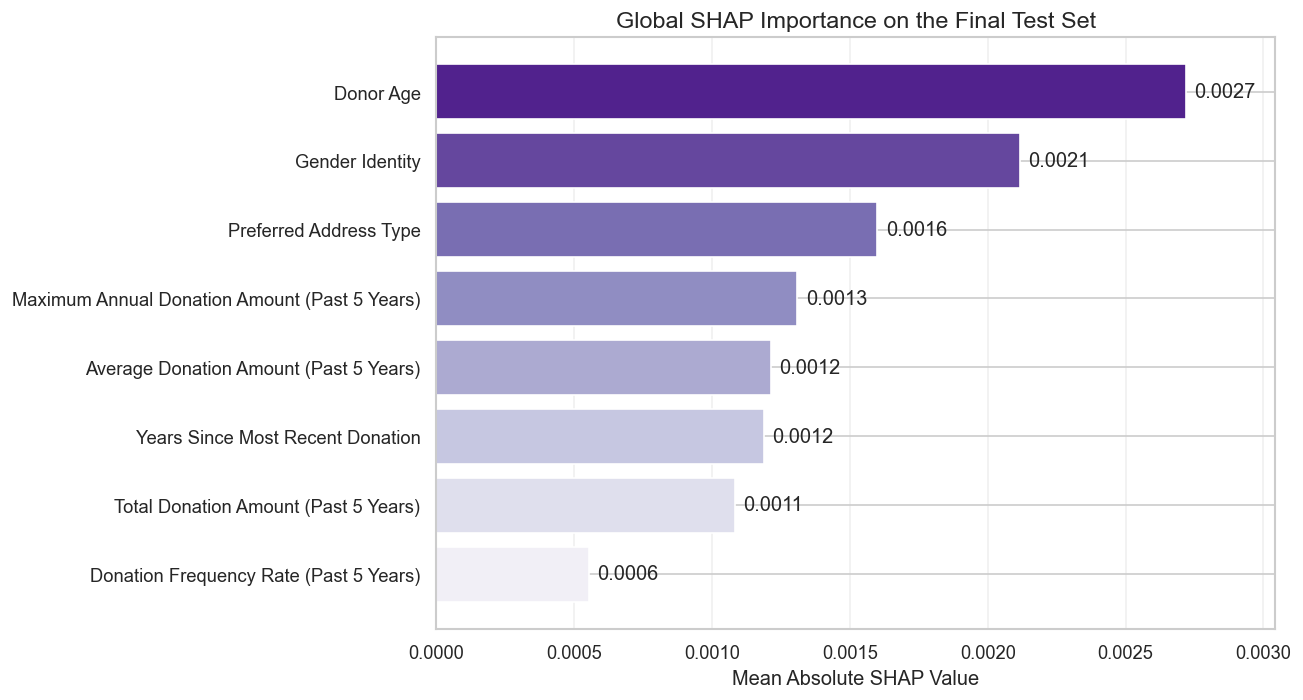

SHAP Rank,Source Feature,Business-Friendly Label,Transformed Columns,Mean Absolute SHAP,Importance Percentage,Cumulative Importance Percentage
1,donor_age,Donor Age,1,0.0027,23.07%,23.07%
2,feature_gender_identity,Gender Identity,3,0.0021,17.97%,41.04%
3,feature_preferred_address_type,Preferred Address Type,5,0.0016,13.58%,54.61%
4,feature_past_5yr_max_donation,Maximum Annual Donation Amount (Past 5 Years),1,0.0013,11.12%,65.73%
5,feature_past_5yr_average_donation,Average Donation Amount (Past 5 Years),1,0.0012,10.29%,76.03%
6,feature_years_since_last_donation_past_5yr,Years Since Most Recent Donation,1,0.0012,10.09%,86.12%
7,feature_past_5yr_total_donation,Total Donation Amount (Past 5 Years),1,0.0011,9.20%,95.31%
8,feature_past_5yr_donation_frequency_rate,Donation Frequency Rate (Past 5 Years),1,0.0006,4.69%,100.00%


SHAP Rank,Transformed Feature,Source Feature,Category Level,Business-Friendly Label,Mean Absolute SHAP,Importance Percentage,Cumulative Importance Percentage
1,donor_age,donor_age,Not applicable,Donor Age,0.002717,21.88%,21.88%
2,feature_past_5yr_max_donation,feature_past_5yr_max_donation,Not applicable,Maximum Annual Donation Amount (Past 5 Years),0.001310,10.55%,32.43%
3,feature_past_5yr_average_donation,feature_past_5yr_average_donation,Not applicable,Average Donation Amount (Past 5 Years),0.001213,9.77%,42.19%
4,feature_years_since_last_donation_past_5yr,feature_years_since_last_donation_past_5yr,Not applicable,Years Since Most Recent Donation,0.001189,9.57%,51.76%
5,feature_gender_identity_Male,feature_gender_identity,Male,Gender Identity: Male,0.001169,9.41%,61.18%
6,feature_past_5yr_total_donation,feature_past_5yr_total_donation,Not applicable,Total Donation Amount (Past 5 Years),0.001083,8.72%,69.90%
7,feature_gender_identity_Female,feature_gender_identity,Female,Gender Identity: Female,0.000804,6.47%,76.37%
8,feature_preferred_address_type_Missing,feature_preferred_address_type,Missing,Preferred Address Type: Missing,0.000789,6.36%,82.73%
9,feature_preferred_address_type_Home,feature_preferred_address_type,Home Address,Preferred Address Type: Home Address,0.000729,5.87%,88.60%
10,feature_past_5yr_donation_frequency_rate,feature_past_5yr_donation_frequency_rate,Not applicable,Donation Frequency Rate (Past 5 Years),0.000552,4.45%,93.05%


Global SHAP importance ranking completed successfully: 19/19 checks passed.
Source SHAP importance saved to: outputs/interpretability/tables/primary_shap_importance_source.csv
Transformed SHAP importance saved to: outputs/interpretability/tables/primary_shap_importance_transformed.csv
Source SHAP values saved to: outputs/interpretability/tables/primary_shap_values_source_final_test.csv
SHAP importance figure saved to: outputs/interpretability/figures/primary_shap_importance_source.png


In [12]:
# Calculate global SHAP importance rankings
mean_absolute_shap_primary_transformed = np.mean(
    np.abs(shap_values_primary_positive),
    axis=0,
)

importance_primary_shap_transformed = (
    mapping_primary_transformed_features.copy()
)

importance_primary_shap_transformed[
    "Mean Absolute SHAP"
] = mean_absolute_shap_primary_transformed

total_shap_importance_primary_transformed = float(
    importance_primary_shap_transformed[
        "Mean Absolute SHAP"
    ].sum()
)

importance_primary_shap_transformed[
    "Importance Percentage"
] = (
    importance_primary_shap_transformed[
        "Mean Absolute SHAP"
    ]
    / total_shap_importance_primary_transformed
    * 100
)

importance_primary_shap_transformed = (
    importance_primary_shap_transformed
    .sort_values(
        "Mean Absolute SHAP",
        ascending=False,
        kind="stable",
    )
    .reset_index(drop=True)
)

importance_primary_shap_transformed.insert(
    0,
    "SHAP Rank",
    np.arange(
        1,
        importance_primary_shap_transformed.shape[0] + 1,
    ),
)

importance_primary_shap_transformed[
    "Cumulative Importance Percentage"
] = (
    importance_primary_shap_transformed[
        "Importance Percentage"
    ].cumsum()
)

business_label_lookup_primary_shap_source = (
    mapping_primary_source_features
    .set_index("Source Feature")[
        "Business-Friendly Label"
    ]
    .to_dict()
)

transformed_count_lookup_primary_shap_source = (
    mapping_primary_source_features
    .set_index("Source Feature")[
        "Transformed Columns"
    ]
    .astype(int)
    .to_dict()
)

source_names_primary_shap_mapping = (
    mapping_primary_transformed_features[
        "Source Feature"
    ].to_numpy()
)

shap_values_primary_source_columns = []

for source_feature_name in features_primary_saved:
    transformed_positions_for_source = np.flatnonzero(
        source_names_primary_shap_mapping
        == source_feature_name
    )

    source_contributions_primary_shap = (
        shap_values_primary_positive[
            :,
            transformed_positions_for_source,
        ].sum(axis=1)
    )

    shap_values_primary_source_columns.append(
        source_contributions_primary_shap
    )

shap_values_primary_source_array = np.column_stack(
    shap_values_primary_source_columns
)

source_shap_value_column_names = [
    f"shap_value_source__{source_feature_name}"
    for source_feature_name
    in features_primary_saved
]

values_primary_shap_source_final_test = pd.DataFrame(
    shap_values_primary_source_array,
    columns=source_shap_value_column_names,
)

values_primary_shap_source_final_test.insert(
    0,
    "test_record_position",
    np.arange(
        1,
        shap_test_record_count + 1,
    ),
)

values_primary_shap_source_final_test.insert(
    1,
    "target_actual_primary_donor_flag",
    target_primary_test_interpretation
    .astype(int)
    .to_numpy(),
)

values_primary_shap_source_final_test.insert(
    2,
    "prob_primary_donor",
    probabilities_primary_classifier_shap,
)

source_shap_importance_records = []

for source_position, source_feature_name in enumerate(
    features_primary_saved,
    start=1,
):
    source_contributions_primary_shap = (
        shap_values_primary_source_array[
            :,
            source_position - 1,
        ]
    )

    source_shap_importance_records.append(
        {
            "Source Position": source_position,
            "Source Feature": source_feature_name,
            "Business-Friendly Label": (
                business_label_lookup_primary_shap_source[
                    source_feature_name
                ]
            ),
            "Transformed Columns": (
                transformed_count_lookup_primary_shap_source[
                    source_feature_name
                ]
            ),
            "Mean Absolute SHAP": float(
                np.mean(
                    np.abs(
                        source_contributions_primary_shap
                    )
                )
            ),
        }
    )

importance_primary_shap_source = pd.DataFrame(
    source_shap_importance_records
)

total_shap_importance_primary_source = float(
    importance_primary_shap_source[
        "Mean Absolute SHAP"
    ].sum()
)

importance_primary_shap_source[
    "Importance Percentage"
] = (
    importance_primary_shap_source[
        "Mean Absolute SHAP"
    ]
    / total_shap_importance_primary_source
    * 100
)

importance_primary_shap_source = (
    importance_primary_shap_source
    .sort_values(
        "Mean Absolute SHAP",
        ascending=False,
        kind="stable",
    )
    .reset_index(drop=True)
)

importance_primary_shap_source.insert(
    0,
    "SHAP Rank",
    np.arange(
        1,
        importance_primary_shap_source.shape[0] + 1,
    ),
)

importance_primary_shap_source[
    "Cumulative Importance Percentage"
] = (
    importance_primary_shap_source[
        "Importance Percentage"
    ].cumsum()
)

PRIMARY_SHAP_TRANSFORMED_IMPORTANCE_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_shap_importance_transformed.csv"
)

PRIMARY_SHAP_SOURCE_IMPORTANCE_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_shap_importance_source.csv"
)

PRIMARY_SHAP_SOURCE_VALUES_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_shap_values_source_final_test.csv"
)

PRIMARY_SHAP_SOURCE_IMPORTANCE_FIGURE_PATH = (
    INTERPRETABILITY_FIGURES_DIR
    / "primary_shap_importance_source.png"
)

importance_primary_shap_transformed.to_csv(
    PRIMARY_SHAP_TRANSFORMED_IMPORTANCE_PATH,
    index=False,
)

importance_primary_shap_source.to_csv(
    PRIMARY_SHAP_SOURCE_IMPORTANCE_PATH,
    index=False,
)

values_primary_shap_source_final_test.to_csv(
    PRIMARY_SHAP_SOURCE_VALUES_PATH,
    index=False,
)

importance_primary_shap_source_plot = (
    importance_primary_shap_source
    .sort_values(
        "Mean Absolute SHAP",
        ascending=True,
    )
)

figure_primary_shap_importance, axis_primary_shap_importance = (
    plt.subplots(figsize=(11, 6))
)

bars_primary_shap_importance = (
    axis_primary_shap_importance.barh(
        importance_primary_shap_source_plot[
            "Business-Friendly Label"
        ],
        importance_primary_shap_source_plot[
            "Mean Absolute SHAP"
        ],
        color=sns.color_palette(
            "Purples",
            n_colors=importance_primary_shap_source_plot.shape[0],
        ),
    )
)

axis_primary_shap_importance.bar_label(
    bars_primary_shap_importance,
    labels=[
        f"{mean_absolute_shap:.4f}"
        for mean_absolute_shap
        in importance_primary_shap_source_plot[
            "Mean Absolute SHAP"
        ]
    ],
    padding=5,
)

axis_primary_shap_importance.set_title(
    "Global SHAP Importance on the Final Test Set"
)
axis_primary_shap_importance.set_xlabel(
    "Mean Absolute SHAP Value"
)
axis_primary_shap_importance.set_ylabel("")
axis_primary_shap_importance.grid(
    axis="x",
    alpha=0.30,
)
axis_primary_shap_importance.margins(x=0.12)

plt.tight_layout()

figure_primary_shap_importance.savefig(
    PRIMARY_SHAP_SOURCE_IMPORTANCE_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

source_shap_reconstructed_outputs = (
    shap_base_values_primary_positive
    + shap_values_primary_source_array.sum(axis=1)
)

source_importance_validation_order = (
    importance_primary_shap_source
    .set_index("Source Feature")
    .loc[features_primary_saved]
)

expected_source_mean_absolute_shap = np.mean(
    np.abs(shap_values_primary_source_array),
    axis=0,
)

global_shap_importance_checks = {
    "SHAP values contain all final test records": (
        shap_values_primary_positive.shape[0]
        == expected_primary_decisions[
            "final_test_records"
        ]
    ),
    "SHAP values contain all transformed features": (
        shap_values_primary_positive.shape[1]
        == expected_primary_decisions[
            "transformed_feature_count"
        ]
        == len(features_primary_transformed)
    ),
    "Transformed feature order is preserved": (
        mapping_primary_transformed_features[
            "Transformed Feature"
        ].tolist()
        == list(features_primary_transformed)
    ),
    "Transformed SHAP values are finite": (
        np.isfinite(
            shap_values_primary_positive
        ).all()
    ),
    "Transformed SHAP importance values are nonnegative": (
        (
            importance_primary_shap_transformed[
                "Mean Absolute SHAP"
            ]
            >= 0
        ).all()
    ),
    "All transformed features are ranked": (
        importance_primary_shap_transformed.shape[0]
        == len(features_primary_transformed)
        == 14
    ),
    "Transformed importance percentages sum to 100": (
        np.isclose(
            importance_primary_shap_transformed[
                "Importance Percentage"
            ].sum(),
            100.0,
            rtol=0,
            atol=1e-10,
        )
    ),
    "Source SHAP matrix has the correct shape": (
        shap_values_primary_source_array.shape
        == (
            expected_primary_decisions[
                "final_test_records"
            ],
            len(features_primary_saved),
        )
    ),
    "Source contributions reproduce transformed contributions": (
        np.allclose(
            shap_values_primary_source_array.sum(axis=1),
            shap_values_primary_positive.sum(axis=1),
            rtol=0,
            atol=1e-12,
        )
    ),
    "Source SHAP values reproduce model outputs": (
        np.allclose(
            source_shap_reconstructed_outputs,
            probabilities_primary_classifier_shap,
            rtol=SHAP_ADDITIVITY_TOLERANCE,
            atol=SHAP_ADDITIVITY_TOLERANCE,
        )
    ),
    "Source SHAP importance values are nonnegative": (
        (
            importance_primary_shap_source[
                "Mean Absolute SHAP"
            ]
            >= 0
        ).all()
    ),
    "All source features are ranked": (
        importance_primary_shap_source.shape[0]
        == len(features_primary_saved)
        == 8
    ),
    "Source importance values reproduce direct calculation": (
        np.allclose(
            source_importance_validation_order[
                "Mean Absolute SHAP"
            ].to_numpy(),
            expected_source_mean_absolute_shap,
            rtol=0,
            atol=1e-12,
        )
    ),
    "Source importance percentages sum to 100": (
        np.isclose(
            importance_primary_shap_source[
                "Importance Percentage"
            ].sum(),
            100.0,
            rtol=0,
            atol=1e-10,
        )
    ),
    "Transformed SHAP ranking is descending": (
        importance_primary_shap_transformed[
            "Mean Absolute SHAP"
        ].is_monotonic_decreasing
        and np.array_equal(
            importance_primary_shap_transformed[
                "SHAP Rank"
            ].to_numpy(),
            np.arange(
                1,
                importance_primary_shap_transformed.shape[0] + 1,
            ),
        )
    ),
    "Source SHAP ranking is descending": (
        importance_primary_shap_source[
            "Mean Absolute SHAP"
        ].is_monotonic_decreasing
        and np.array_equal(
            importance_primary_shap_source[
                "SHAP Rank"
            ].to_numpy(),
            np.arange(
                1,
                importance_primary_shap_source.shape[0] + 1,
            ),
        )
    ),
    "All SHAP features have business labels": (
        importance_primary_shap_transformed[
            "Business-Friendly Label"
        ].notna().all()
        and importance_primary_shap_source[
            "Business-Friendly Label"
        ].notna().all()
    ),
    "Saved source SHAP values preserve privacy and row order": (
        "donor_unique_id"
        not in values_primary_shap_source_final_test.columns
        and np.array_equal(
            values_primary_shap_source_final_test[
                "test_record_position"
            ].to_numpy(),
            np.arange(
                1,
                shap_test_record_count + 1,
            ),
        )
    ),
    "Global SHAP artifacts were saved": (
        PRIMARY_SHAP_TRANSFORMED_IMPORTANCE_PATH.exists()
        and PRIMARY_SHAP_SOURCE_IMPORTANCE_PATH.exists()
        and PRIMARY_SHAP_SOURCE_VALUES_PATH.exists()
        and PRIMARY_SHAP_SOURCE_IMPORTANCE_FIGURE_PATH.exists()
    ),
}

failed_global_shap_importance_checks = [
    check_name
    for check_name, check_passed
    in global_shap_importance_checks.items()
    if not check_passed
]

if failed_global_shap_importance_checks:
    raise AssertionError(
        "Global SHAP importance validation failed for: "
        + ", ".join(
            failed_global_shap_importance_checks
        )
    )

display(
    importance_primary_shap_source[
        [
            "SHAP Rank",
            "Source Feature",
            "Business-Friendly Label",
            "Transformed Columns",
            "Mean Absolute SHAP",
            "Importance Percentage",
            "Cumulative Importance Percentage",
        ]
    ].style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "SHAP Rank": "{:,.0f}",
            "Source Feature": "{}",
            "Business-Friendly Label": "{}",
            "Transformed Columns": "{:,.0f}",
            "Mean Absolute SHAP": "{:,.4f}",
            "Importance Percentage": "{:,.2f}%",
            "Cumulative Importance Percentage": "{:,.2f}%",
        }
    )
)

display(
    importance_primary_shap_transformed[
        [
            "SHAP Rank",
            "Transformed Feature",
            "Source Feature",
            "Category Level",
            "Business-Friendly Label",
            "Mean Absolute SHAP",
            "Importance Percentage",
            "Cumulative Importance Percentage",
        ]
    ].style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "SHAP Rank": "{:,.0f}",
            "Transformed Feature": "{}",
            "Source Feature": "{}",
            "Category Level": "{}",
            "Business-Friendly Label": "{}",
            "Mean Absolute SHAP": "{:,.6f}",
            "Importance Percentage": "{:,.2f}%",
            "Cumulative Importance Percentage": "{:,.2f}%",
        }
    )
)

print(
    "Global SHAP importance ranking completed successfully: "
    f"{sum(global_shap_importance_checks.values())}/"
    f"{len(global_shap_importance_checks)} checks passed."
)
print(
    "Source SHAP importance saved to: "
    f"{PRIMARY_SHAP_SOURCE_IMPORTANCE_PATH.relative_to(PROJECT_ROOT)}"
)
print(
    "Transformed SHAP importance saved to: "
    f"{PRIMARY_SHAP_TRANSFORMED_IMPORTANCE_PATH.relative_to(PROJECT_ROOT)}"
)
print(
    "Source SHAP values saved to: "
    f"{PRIMARY_SHAP_SOURCE_VALUES_PATH.relative_to(PROJECT_ROOT)}"
)
print(
    "SHAP importance figure saved to: "
    f"{PRIMARY_SHAP_SOURCE_IMPORTANCE_FIGURE_PATH.relative_to(PROJECT_ROOT)}"
)

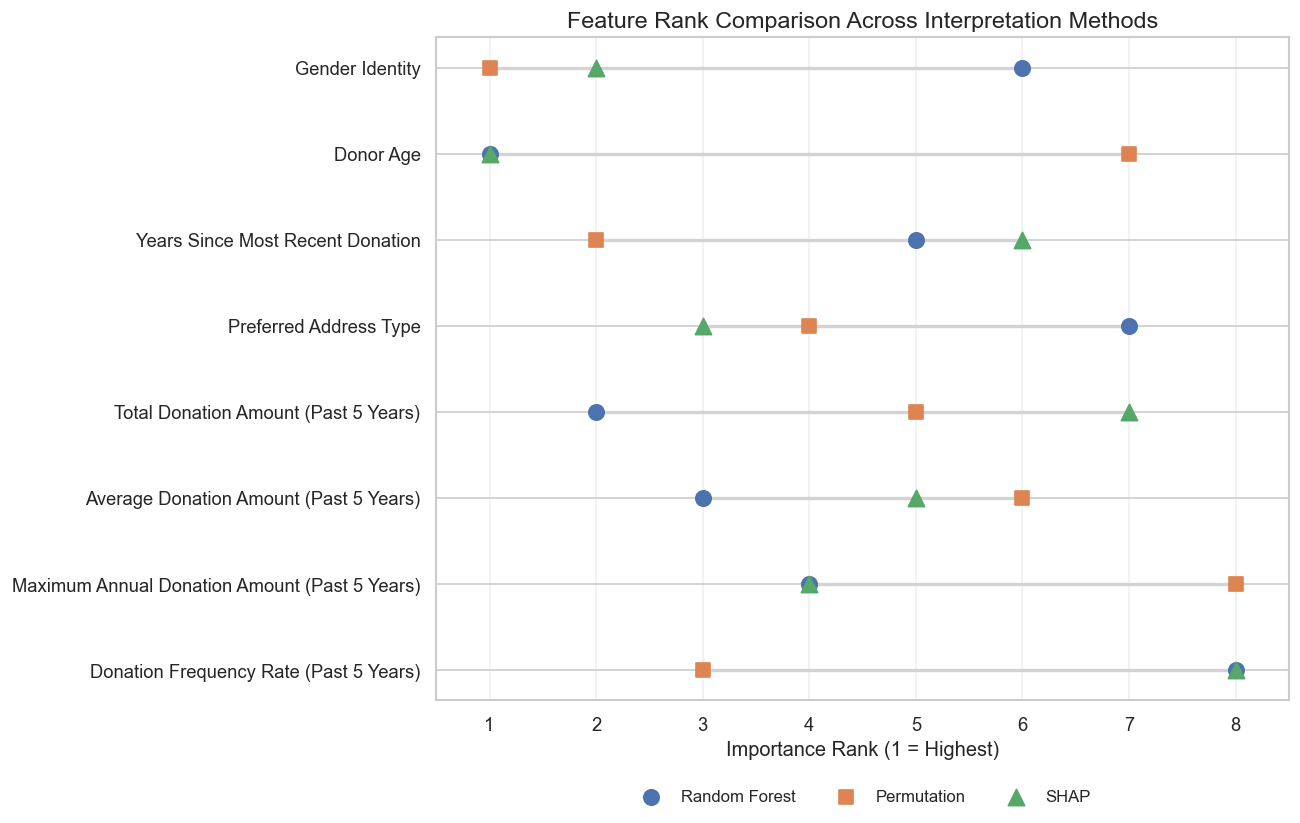

Consensus Rank,Source Feature,Business-Friendly Label,Random Forest Rank,Permutation Rank,SHAP Rank,Mean Rank,Rank Range,Top Four Method Count,Stable Positive Permutation,Support Classification
1,feature_gender_identity,Gender Identity,6,1,2,3.00,5,2,Yes,Consistent Held Out Support
2,donor_age,Donor Age,1,7,1,3.00,6,2,No,Model Structure Support Only
3,feature_years_since_last_donation_past_5yr,Years Since Most Recent Donation,5,2,6,4.33,4,1,Yes,Stable Held Out Support
4,feature_preferred_address_type,Preferred Address Type,7,4,3,4.67,4,2,No,Moderate Cross Method Support
5,feature_past_5yr_total_donation,Total Donation Amount (Past 5 Years),2,5,7,4.67,5,1,No,Mixed Support
6,feature_past_5yr_average_donation,Average Donation Amount (Past 5 Years),3,6,5,4.67,3,1,No,Mixed Support
7,feature_past_5yr_max_donation,Maximum Annual Donation Amount (Past 5 Years),4,8,4,5.33,4,2,No,Model Structure Support Only
8,feature_past_5yr_donation_frequency_rate,Donation Frequency Rate (Past 5 Years),8,3,8,6.33,5,1,No,Mixed Support


Business-Friendly Label,Random Forest Importance Percentage,Mean PR AUC Decrease,Positive Repeat Percentage,Lower Percentile (2.5%),Upper Percentile (97.5%),Mean Absolute SHAP,SHAP Importance Percentage
Gender Identity,3.82%,0.0034,96.67%,0.0006,0.0066,0.0021,17.97%
Donor Age,25.22%,-0.0012,33.33%,-0.0060,0.0025,0.0027,23.07%
Years Since Most Recent Donation,4.70%,0.0027,100.00%,0.0002,0.0053,0.0012,10.09%
Preferred Address Type,3.20%,0.0008,70.00%,-0.0032,0.0044,0.0016,13.58%
Total Donation Amount (Past 5 Years),20.88%,0.0004,60.00%,-0.0035,0.0040,0.0011,9.20%
Average Donation Amount (Past 5 Years),20.84%,0.0002,56.67%,-0.0036,0.0037,0.0012,10.29%
Maximum Annual Donation Amount (Past 5 Years),18.47%,-0.0012,30.00%,-0.0051,0.0026,0.0013,11.12%
Donation Frequency Rate (Past 5 Years),2.87%,0.0015,90.00%,-0.0006,0.0034,0.0006,4.69%


,Random Forest Rank,Permutation Rank,SHAP Rank
Random Forest Rank,1.00,-0.64,0.26
Permutation Rank,-0.64,1.00,-0.19
SHAP Rank,0.26,-0.19,1.00


Importance method comparison completed successfully: 18/18 checks passed.
Importance comparison saved to: outputs/interpretability/tables/primary_importance_method_comparison.csv
Rank correlations saved to: outputs/interpretability/tables/primary_importance_rank_correlations.csv
Rank comparison figure saved to: outputs/interpretability/figures/primary_importance_rank_comparison.png


In [13]:
# Compare feature importance across three methods
IMPORTANCE_TOP_RANK_THRESHOLD = int(
    np.ceil(
        len(features_primary_saved) / 2
    )
)

comparison_primary_random_forest = (
    importance_primary_source[
        [
            "Source Feature",
            "Business-Friendly Label",
            "Importance Rank",
            "Importance Percentage",
        ]
    ]
    .rename(
        columns={
            "Importance Rank": "Random Forest Rank",
            "Importance Percentage": (
                "Random Forest Importance Percentage"
            ),
        }
    )
)

comparison_primary_permutation = (
    importance_primary_permutation[
        [
            "Source Feature",
            "Permutation Rank",
            "Mean PR AUC Decrease",
            "Lower Percentile (2.5%)",
            "Upper Percentile (97.5%)",
            "Positive Repeat Percentage",
        ]
    ].copy()
)

comparison_primary_shap = (
    importance_primary_shap_source[
        [
            "Source Feature",
            "SHAP Rank",
            "Mean Absolute SHAP",
            "Importance Percentage",
        ]
    ]
    .rename(
        columns={
            "Importance Percentage": (
                "SHAP Importance Percentage"
            ),
        }
    )
)

comparison_primary_importance_methods = (
    comparison_primary_random_forest
    .merge(
        comparison_primary_permutation,
        on="Source Feature",
        how="inner",
        validate="one_to_one",
    )
    .merge(
        comparison_primary_shap,
        on="Source Feature",
        how="inner",
        validate="one_to_one",
    )
)

rank_columns_primary_importance = [
    "Random Forest Rank",
    "Permutation Rank",
    "SHAP Rank",
]

comparison_primary_importance_methods[
    "Mean Rank"
] = (
    comparison_primary_importance_methods[
        rank_columns_primary_importance
    ].mean(axis=1)
)

comparison_primary_importance_methods[
    "Rank Range"
] = (
    comparison_primary_importance_methods[
        rank_columns_primary_importance
    ].max(axis=1)
    - comparison_primary_importance_methods[
        rank_columns_primary_importance
    ].min(axis=1)
)

comparison_primary_importance_methods[
    "Random Forest Top Four"
] = (
    comparison_primary_importance_methods[
        "Random Forest Rank"
    ]
    <= IMPORTANCE_TOP_RANK_THRESHOLD
)

comparison_primary_importance_methods[
    "Permutation Top Four"
] = (
    (
        comparison_primary_importance_methods[
            "Permutation Rank"
        ]
        <= IMPORTANCE_TOP_RANK_THRESHOLD
    )
    & (
        comparison_primary_importance_methods[
            "Mean PR AUC Decrease"
        ]
        > 0
    )
)

comparison_primary_importance_methods[
    "SHAP Top Four"
] = (
    comparison_primary_importance_methods[
        "SHAP Rank"
    ]
    <= IMPORTANCE_TOP_RANK_THRESHOLD
)

comparison_primary_importance_methods[
    "Top Four Method Count"
] = (
    comparison_primary_importance_methods[
        [
            "Random Forest Top Four",
            "Permutation Top Four",
            "SHAP Top Four",
        ]
    ]
    .sum(axis=1)
    .astype(int)
)

comparison_primary_importance_methods[
    "Stable Positive Permutation"
] = (
    comparison_primary_importance_methods[
        "Lower Percentile (2.5%)"
    ]
    > 0
)


def classify_importance_support(
    comparison_row,
):
    random_forest_top = comparison_row[
        "Random Forest Top Four"
    ]
    permutation_top = comparison_row[
        "Permutation Top Four"
    ]
    shap_top = comparison_row[
        "SHAP Top Four"
    ]
    stable_permutation = comparison_row[
        "Stable Positive Permutation"
    ]
    positive_permutation = (
        comparison_row[
            "Mean PR AUC Decrease"
        ]
        > 0
    )
    top_method_count = comparison_row[
        "Top Four Method Count"
    ]

    if (
        random_forest_top
        and permutation_top
        and shap_top
        and stable_permutation
    ):
        return "Strong Support Across All Methods"

    if (
        stable_permutation
        and top_method_count >= 2
    ):
        return "Consistent Held Out Support"

    if stable_permutation:
        return "Stable Held Out Support"

    if (
        positive_permutation
        and top_method_count >= 2
    ):
        return "Moderate Cross Method Support"

    if (
        random_forest_top
        and shap_top
        and not positive_permutation
    ):
        return "Model Structure Support Only"

    if top_method_count >= 1:
        return "Mixed Support"

    return "Limited Support"


comparison_primary_importance_methods[
    "Support Classification"
] = (
    comparison_primary_importance_methods.apply(
        classify_importance_support,
        axis=1,
    )
)

comparison_primary_importance_methods = (
    comparison_primary_importance_methods
    .sort_values(
        [
            "Mean Rank",
            "Top Four Method Count",
            "Positive Repeat Percentage",
        ],
        ascending=[
            True,
            False,
            False,
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

comparison_primary_importance_methods.insert(
    0,
    "Consensus Rank",
    np.arange(
        1,
        comparison_primary_importance_methods.shape[0] + 1,
    ),
)

correlation_primary_importance_ranks = (
    comparison_primary_importance_methods[
        rank_columns_primary_importance
    ]
    .corr(method="spearman")
)

comparison_primary_importance_display = (
    comparison_primary_importance_methods.copy()
)

comparison_primary_importance_display[
    "Stable Positive Permutation"
] = np.where(
    comparison_primary_importance_display[
        "Stable Positive Permutation"
    ],
    "Yes",
    "No",
)

PRIMARY_IMPORTANCE_METHOD_COMPARISON_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_importance_method_comparison.csv"
)

PRIMARY_IMPORTANCE_RANK_CORRELATION_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_importance_rank_correlations.csv"
)

PRIMARY_IMPORTANCE_RANK_FIGURE_PATH = (
    INTERPRETABILITY_FIGURES_DIR
    / "primary_importance_rank_comparison.png"
)

comparison_primary_importance_methods.to_csv(
    PRIMARY_IMPORTANCE_METHOD_COMPARISON_PATH,
    index=False,
)

correlation_primary_importance_ranks.to_csv(
    PRIMARY_IMPORTANCE_RANK_CORRELATION_PATH,
)

comparison_primary_importance_plot = (
    comparison_primary_importance_methods
    .sort_values(
        "Consensus Rank",
        ascending=True,
    )
)

plot_positions_primary_importance = np.arange(
    comparison_primary_importance_plot.shape[0]
)

figure_primary_importance_comparison, axis_primary_importance_comparison = (
    plt.subplots(figsize=(11, 7))
)

for plot_position, comparison_row in (
    comparison_primary_importance_plot.iterrows()
):
    row_ranks = comparison_row[
        rank_columns_primary_importance
    ].astype(float)

    axis_primary_importance_comparison.hlines(
        y=plot_position,
        xmin=row_ranks.min(),
        xmax=row_ranks.max(),
        color="lightgray",
        linewidth=2,
        zorder=1,
    )

axis_primary_importance_comparison.scatter(
    comparison_primary_importance_plot[
        "Random Forest Rank"
    ],
    plot_positions_primary_importance,
    label="Random Forest",
    marker="o",
    s=85,
    zorder=3,
)

axis_primary_importance_comparison.scatter(
    comparison_primary_importance_plot[
        "Permutation Rank"
    ],
    plot_positions_primary_importance,
    label="Permutation",
    marker="s",
    s=80,
    zorder=3,
)

axis_primary_importance_comparison.scatter(
    comparison_primary_importance_plot[
        "SHAP Rank"
    ],
    plot_positions_primary_importance,
    label="SHAP",
    marker="^",
    s=95,
    zorder=3,
)

axis_primary_importance_comparison.set_yticks(
    plot_positions_primary_importance
)

axis_primary_importance_comparison.set_yticklabels(
    comparison_primary_importance_plot[
        "Business-Friendly Label"
    ]
)

axis_primary_importance_comparison.invert_yaxis()

axis_primary_importance_comparison.set_xticks(
    np.arange(
        1,
        len(features_primary_saved) + 1,
    )
)

axis_primary_importance_comparison.set_xlim(
    0.5,
    len(features_primary_saved) + 0.5,
)

axis_primary_importance_comparison.set_title(
    "Feature Rank Comparison Across Interpretation Methods"
)

axis_primary_importance_comparison.set_xlabel(
    "Importance Rank (1 = Highest)"
)

axis_primary_importance_comparison.set_ylabel("")

axis_primary_importance_comparison.grid(
    axis="x",
    alpha=0.30,
)

axis_primary_importance_comparison.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=3,
    frameon=False,
)

plt.tight_layout()

figure_primary_importance_comparison.savefig(
    PRIMARY_IMPORTANCE_RANK_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

comparison_primary_source_order = (
    comparison_primary_importance_methods
    .set_index("Source Feature")
    .loc[features_primary_saved]
)

random_forest_primary_source_order = (
    importance_primary_source
    .set_index("Source Feature")
    .loc[features_primary_saved]
)

permutation_primary_source_order = (
    importance_primary_permutation
    .set_index("Source Feature")
    .loc[features_primary_saved]
)

shap_primary_source_order = (
    importance_primary_shap_source
    .set_index("Source Feature")
    .loc[features_primary_saved]
)

comparison_rank_values = (
    comparison_primary_importance_methods[
        rank_columns_primary_importance
    ].to_numpy()
)

expected_mean_ranks = comparison_rank_values.mean(
    axis=1
)

expected_rank_ranges = (
    comparison_rank_values.max(axis=1)
    - comparison_rank_values.min(axis=1)
)

expected_top_four_counts = (
    comparison_primary_importance_methods[
        [
            "Random Forest Top Four",
            "Permutation Top Four",
            "SHAP Top Four",
        ]
    ]
    .sum(axis=1)
    .astype(int)
    .to_numpy()
)

importance_method_comparison_checks = {
    "All eight source features are compared": (
        comparison_primary_importance_methods.shape[0]
        == len(features_primary_saved)
        == 8
    ),
    "Source feature identities are complete": (
        set(
            comparison_primary_importance_methods[
                "Source Feature"
            ]
        )
        == set(features_primary_saved)
    ),
    "Source features are unique": (
        comparison_primary_importance_methods[
            "Source Feature"
        ].is_unique
    ),
    "Comparison table contains no missing values": (
        comparison_primary_importance_methods
        .notna()
        .all()
        .all()
    ),
    "Random Forest ranks are complete": (
        set(
            comparison_primary_importance_methods[
                "Random Forest Rank"
            ].astype(int)
        )
        == set(
            range(
                1,
                len(features_primary_saved) + 1,
            )
        )
    ),
    "Permutation ranks are complete": (
        set(
            comparison_primary_importance_methods[
                "Permutation Rank"
            ].astype(int)
        )
        == set(
            range(
                1,
                len(features_primary_saved) + 1,
            )
        )
    ),
    "SHAP ranks are complete": (
        set(
            comparison_primary_importance_methods[
                "SHAP Rank"
            ].astype(int)
        )
        == set(
            range(
                1,
                len(features_primary_saved) + 1,
            )
        )
    ),
    "Random Forest metrics match the source ranking": (
        np.allclose(
            comparison_primary_source_order[
                "Random Forest Importance Percentage"
            ].to_numpy(),
            random_forest_primary_source_order[
                "Importance Percentage"
            ].to_numpy(),
            rtol=0,
            atol=1e-12,
        )
    ),
    "Permutation metrics match the source ranking": (
        np.allclose(
            comparison_primary_source_order[
                "Mean PR AUC Decrease"
            ].to_numpy(),
            permutation_primary_source_order[
                "Mean PR AUC Decrease"
            ].to_numpy(),
            rtol=0,
            atol=1e-12,
        )
    ),
    "SHAP metrics match the source ranking": (
        np.allclose(
            comparison_primary_source_order[
                "Mean Absolute SHAP"
            ].to_numpy(),
            shap_primary_source_order[
                "Mean Absolute SHAP"
            ].to_numpy(),
            rtol=0,
            atol=1e-12,
        )
    ),
    "Mean ranks are calculated correctly": (
        np.allclose(
            comparison_primary_importance_methods[
                "Mean Rank"
            ].to_numpy(),
            expected_mean_ranks,
            rtol=0,
            atol=1e-12,
        )
    ),
    "Rank ranges are calculated correctly": (
        np.array_equal(
            comparison_primary_importance_methods[
                "Rank Range"
            ].to_numpy(),
            expected_rank_ranges,
        )
    ),
    "Top four method counts are correct": (
        np.array_equal(
            comparison_primary_importance_methods[
                "Top Four Method Count"
            ].to_numpy(),
            expected_top_four_counts,
        )
    ),
    "Stable permutation flags match the percentile rule": (
        np.array_equal(
            comparison_primary_importance_methods[
                "Stable Positive Permutation"
            ].to_numpy(),
            (
                comparison_primary_importance_methods[
                    "Lower Percentile (2.5%)"
                ]
                > 0
            ).to_numpy(),
        )
    ),
    "Consensus ranks are complete": (
        np.array_equal(
            comparison_primary_importance_methods[
                "Consensus Rank"
            ].to_numpy(),
            np.arange(
                1,
                comparison_primary_importance_methods.shape[0] + 1,
            ),
        )
        and comparison_primary_importance_methods[
            "Mean Rank"
        ].is_monotonic_increasing
    ),
    "Rank correlation matrix is valid": (
        correlation_primary_importance_ranks.shape
        == (3, 3)
        and np.allclose(
            correlation_primary_importance_ranks,
            correlation_primary_importance_ranks.T,
            rtol=0,
            atol=1e-12,
        )
        and np.allclose(
            np.diag(
                correlation_primary_importance_ranks
            ),
            1.0,
            rtol=0,
            atol=1e-12,
        )
    ),
    "All features have business labels and support classes": (
        comparison_primary_importance_methods[
            "Business-Friendly Label"
        ].notna().all()
        and comparison_primary_importance_methods[
            "Support Classification"
        ].notna().all()
    ),
    "Comparison artifacts were saved": (
        PRIMARY_IMPORTANCE_METHOD_COMPARISON_PATH.exists()
        and PRIMARY_IMPORTANCE_RANK_CORRELATION_PATH.exists()
        and PRIMARY_IMPORTANCE_RANK_FIGURE_PATH.exists()
    ),
}

failed_importance_method_comparison_checks = [
    check_name
    for check_name, check_passed
    in importance_method_comparison_checks.items()
    if not check_passed
]

if failed_importance_method_comparison_checks:
    raise AssertionError(
        "Importance method comparison failed for: "
        + ", ".join(
            failed_importance_method_comparison_checks
        )
    )

display(
    comparison_primary_importance_display[
        [
            "Consensus Rank",
            "Source Feature",
            "Business-Friendly Label",
            "Random Forest Rank",
            "Permutation Rank",
            "SHAP Rank",
            "Mean Rank",
            "Rank Range",
            "Top Four Method Count",
            "Stable Positive Permutation",
            "Support Classification",
        ]
    ].style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Consensus Rank": "{:,.0f}",
            "Source Feature": "{}",
            "Business-Friendly Label": "{}",
            "Random Forest Rank": "{:,.0f}",
            "Permutation Rank": "{:,.0f}",
            "SHAP Rank": "{:,.0f}",
            "Mean Rank": "{:,.2f}",
            "Rank Range": "{:,.0f}",
            "Top Four Method Count": "{:,.0f}",
            "Stable Positive Permutation": "{}",
            "Support Classification": "{}",
        }
    )
)

display(
    comparison_primary_importance_display[
        [
            "Business-Friendly Label",
            "Random Forest Importance Percentage",
            "Mean PR AUC Decrease",
            "Positive Repeat Percentage",
            "Lower Percentile (2.5%)",
            "Upper Percentile (97.5%)",
            "Mean Absolute SHAP",
            "SHAP Importance Percentage",
        ]
    ].style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Business-Friendly Label": "{}",
            "Random Forest Importance Percentage": "{:,.2f}%",
            "Mean PR AUC Decrease": "{:,.4f}",
            "Positive Repeat Percentage": "{:,.2f}%",
            "Lower Percentile (2.5%)": "{:,.4f}",
            "Upper Percentile (97.5%)": "{:,.4f}",
            "Mean Absolute SHAP": "{:,.4f}",
            "SHAP Importance Percentage": "{:,.2f}%",
        }
    )
)

display(
    correlation_primary_importance_ranks.style
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Random Forest Rank": "{:,.2f}",
            "Permutation Rank": "{:,.2f}",
            "SHAP Rank": "{:,.2f}",
        }
    )
)

print(
    "Importance method comparison completed successfully: "
    f"{sum(importance_method_comparison_checks.values())}/"
    f"{len(importance_method_comparison_checks)} checks passed."
)
print(
    "Importance comparison saved to: "
    f"{PRIMARY_IMPORTANCE_METHOD_COMPARISON_PATH.relative_to(PROJECT_ROOT)}"
)
print(
    "Rank correlations saved to: "
    f"{PRIMARY_IMPORTANCE_RANK_CORRELATION_PATH.relative_to(PROJECT_ROOT)}"
)
print(
    "Rank comparison figure saved to: "
    f"{PRIMARY_IMPORTANCE_RANK_FIGURE_PATH.relative_to(PROJECT_ROOT)}"
)

## Global SHAP Importance and Method Comparison

Global SHAP importance was calculated using the mean absolute SHAP value for every feature across the final test set. The 14 transformed features were also combined into the eight original source features. For categorical predictors, the encoded SHAP contributions were added for each donor before calculating the source level importance.

### Global SHAP Findings
- Donor age ranked first with 23.07% of total SHAP importance.
- Gender identity ranked second with 17.97%.
- Preferred address type ranked third with 13.58%.
- The top three features account for 54.61% of total SHAP importance.
- The five historical donation features collectively account for 45.39%.
- Donation frequency rate ranked last with 4.69%.

Mean absolute SHAP measures the average size of each feature’s contribution but does not show whether the contribution raises or lowers the donor score. All 19 global SHAP validation checks passed, and the source and transformed rankings were saved with the source SHAP values and importance figure.

### Importance Method Comparison

The Random Forest, permutation, and SHAP rankings were compared using their rank positions and original importance metrics. The comparison also evaluated whether each feature had a stable positive permutation effect on final test PR AUC.

- Gender identity received the strongest combined support. It ranked first for permutation importance, second for SHAP, and sixth for Random Forest importance.
- Donor age ranked second by consensus but received model structure support only. It ranked first for Random Forest and SHAP but seventh for permutation importance with a negative average effect.
- Years since the most recent donation ranked third by consensus and showed stable held out support. Its permutation effect remained positive across all repetitions.
- Preferred address type received moderate support from permutation and SHAP, although its permutation range crossed zero.
- Maximum annual donation amount ranked fourth for Random Forest and SHAP but last for permutation importance.
- No feature received strong support across all three methods.

The rank correlations were -0.64 between Random Forest and permutation importance, 0.26 between Random Forest and SHAP, and -0.19 between permutation importance and SHAP. These results show that the methods measure different parts of model behavior. Random Forest importance measures split usage, permutation importance measures the effect on final test performance, and SHAP measures average contribution size. Related donation variables may also compensate for one another when one feature is shuffled.

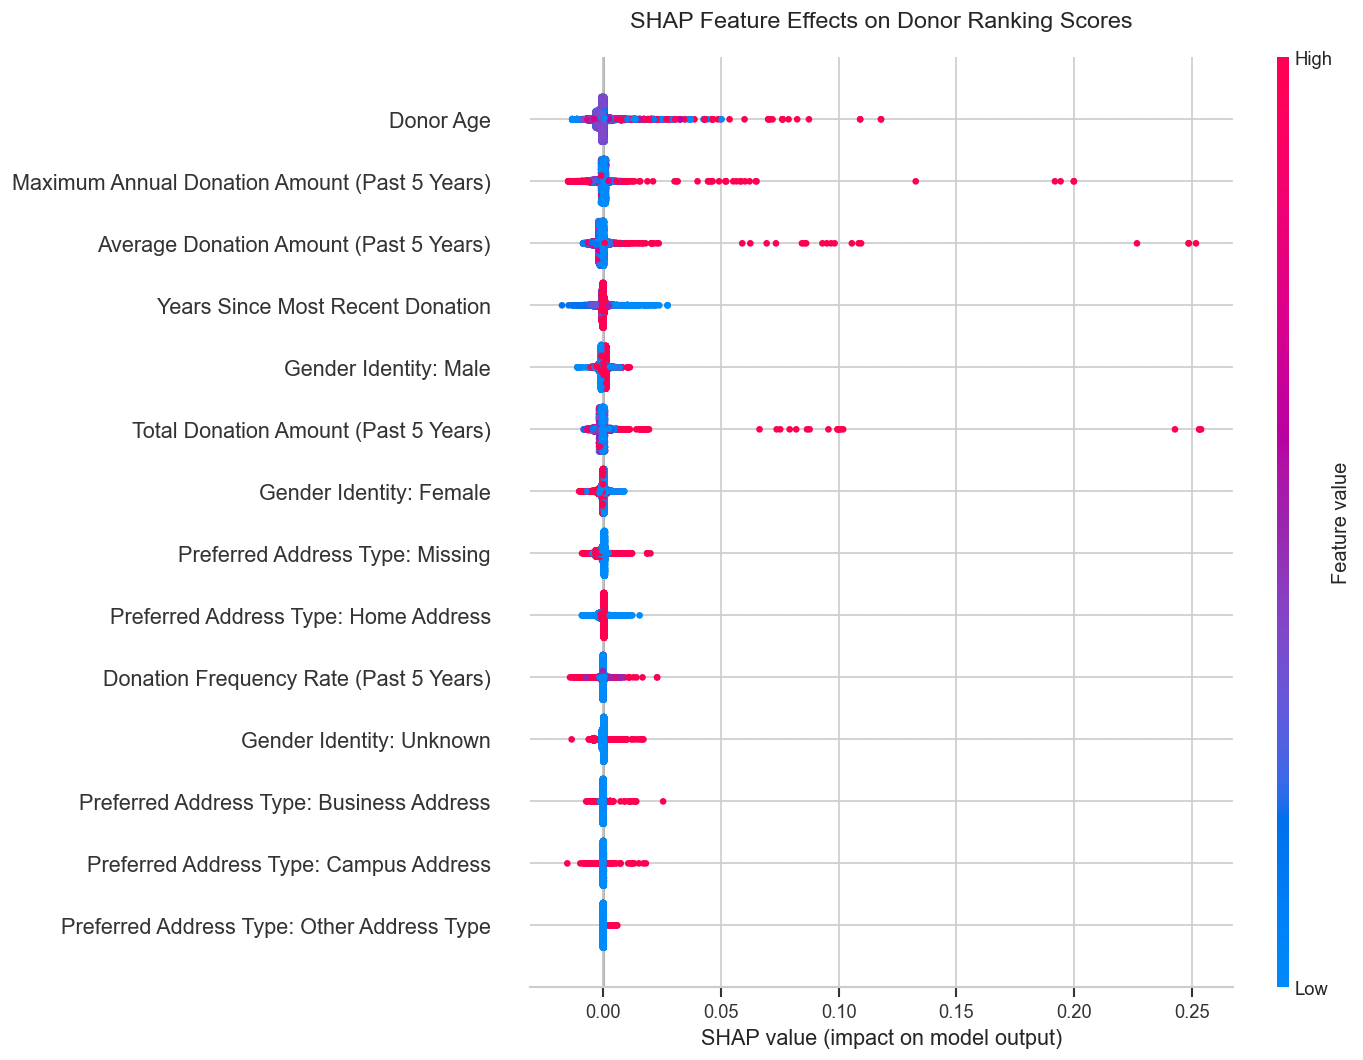

SHAP Rank,Source Feature,Business-Friendly Label,Records Used,Missing Records,Spearman Correlation,Direction Strength,Lower Value Threshold,Higher Value Threshold,Lower Group Mean SHAP,Higher Group Mean SHAP,Higher Minus Lower Mean SHAP,General Direction
1,donor_age,Donor Age,"6,881",0,0.1594,Weak,41.0000,43.0000,0.000327,0.004036,0.003709,Higher Values Generally Increase Score
4,feature_past_5yr_max_donation,Maximum Annual Donation Amount (Past 5 Years),"6,881",0,-0.2233,Weak,0.0000,1.0000,0.000219,-0.000179,-0.000398,Lower Values Generally Increase Score
5,feature_past_5yr_average_donation,Average Donation Amount (Past 5 Years),"6,881",0,-0.2490,Weak,0.0000,0.2000,-0.000054,-0.000003,0.000052,Weak or Near Neutral Pattern
6,feature_years_since_last_donation_past_5yr,Years Since Most Recent Donation,"6,881",0,0.0963,Minimal,4.0000,6.0000,-0.000035,-0.000077,-0.000043,Weak or Near Neutral Pattern
7,feature_past_5yr_total_donation,Total Donation Amount (Past 5 Years),"6,881",0,-0.1447,Weak,0.0000,1.0000,-0.000132,0.000610,0.000742,Mixed or Nonlinear Pattern
8,feature_past_5yr_donation_frequency_rate,Donation Frequency Rate (Past 5 Years),"6,881",0,-0.0818,Minimal,0.0000,0.2000,-0.000084,-0.000257,-0.000173,Lower Values Generally Increase Score


SHAP Rank,Source Feature,Business-Friendly Label,Category Level,Records,Record Percentage,Mean SHAP,Median SHAP,Positive Contribution Percentage,Mean Model Score,General Direction
2,feature_gender_identity,Gender Identity,Male,"3,248",47.20%,0.000706,0.001691,66.90%,0.0564,Generally Increases Score
2,feature_gender_identity,Gender Identity,Female,"3,345",48.61%,-0.001049,-0.000744,16.83%,0.0541,Generally Decreases Score
2,feature_gender_identity,Gender Identity,Unknown,288,4.19%,-0.002541,-0.006404,24.65%,0.0529,Generally Decreases Score
3,feature_preferred_address_type,Preferred Address Type,Other Address Type,19,0.28%,0.004231,0.003660,100.00%,0.0578,Generally Increases Score
3,feature_preferred_address_type,Preferred Address Type,Business Address,180,2.62%,0.001360,0.001187,73.33%,0.0541,Generally Increases Score
3,feature_preferred_address_type,Preferred Address Type,Home Address,"5,769",83.84%,0.000146,0.000482,69.60%,0.0555,Generally Increases Score
3,feature_preferred_address_type,Preferred Address Type,Missing,777,11.29%,-0.002491,-0.002729,18.79%,0.0526,Generally Decreases Score
3,feature_preferred_address_type,Preferred Address Type,Campus Address,136,1.98%,-0.002647,-0.004029,29.41%,0.0539,Generally Decreases Score


SHAP feature direction analysis completed successfully: 19/19 checks passed.
Numeric direction summary saved to: outputs/interpretability/tables/primary_shap_numeric_direction.csv
Categorical direction summary saved to: outputs/interpretability/tables/primary_shap_categorical_direction.csv
SHAP direction figure saved to: outputs/interpretability/figures/primary_shap_direction_beeswarm.png


In [15]:
# Analyze SHAP contribution direction for each source feature
numeric_features_primary_direction = (
    mapping_primary_source_features.loc[
        mapping_primary_source_features[
            "Representation"
        ]
        == "Numeric",
        "Source Feature",
    ].tolist()
)

categorical_features_primary_direction = (
    mapping_primary_source_features.loc[
        mapping_primary_source_features[
            "Representation"
        ]
        == "One-Hot Encoded",
        "Source Feature",
    ].tolist()
)

source_position_lookup_primary_direction = {
    source_feature_name: source_position
    for source_position, source_feature_name
    in enumerate(features_primary_saved)
}

source_shap_rank_lookup_primary_direction = (
    importance_primary_shap_source
    .set_index("Source Feature")[
        "SHAP Rank"
    ]
    .astype(int)
    .to_dict()
)

source_business_label_lookup_primary_direction = (
    mapping_primary_source_features
    .set_index("Source Feature")[
        "Business-Friendly Label"
    ]
    .to_dict()
)


def determine_direction_strength(
    correlation_value,
):
    absolute_correlation = abs(correlation_value)

    if absolute_correlation >= 0.50:
        return "Strong"

    if absolute_correlation >= 0.30:
        return "Moderate"

    if absolute_correlation >= 0.10:
        return "Weak"

    return "Minimal"


def determine_numeric_direction(
    correlation_value,
    high_minus_low_shap,
):
    if (
        abs(correlation_value)
        < DIRECTION_MINIMUM_CORRELATION
        or abs(high_minus_low_shap)
        < DIRECTION_NEUTRAL_SHAP_TOLERANCE
    ):
        return "Weak or Near Neutral Pattern"

    if (
        correlation_value > 0
        and high_minus_low_shap > 0
    ):
        return "Higher Values Generally Increase Score"

    if (
        correlation_value < 0
        and high_minus_low_shap < 0
    ):
        return "Lower Values Generally Increase Score"

    return "Mixed or Nonlinear Pattern"


def determine_category_direction(
    mean_shap_value,
):
    if (
        mean_shap_value
        > DIRECTION_NEUTRAL_SHAP_TOLERANCE
    ):
        return "Generally Increases Score"

    if (
        mean_shap_value
        < -DIRECTION_NEUTRAL_SHAP_TOLERANCE
    ):
        return "Generally Decreases Score"

    return "Near Neutral"


def determine_disjoint_value_thresholds(
    numeric_values,
):
    unique_numeric_values = np.sort(
        numeric_values.unique()
    )

    if unique_numeric_values.size < 2:
        return (
            float(unique_numeric_values[0]),
            float(unique_numeric_values[0]),
        )

    lower_threshold = float(
        numeric_values.quantile(0.25)
    )

    upper_threshold = float(
        numeric_values.quantile(0.75)
    )

    if lower_threshold < upper_threshold:
        return (
            lower_threshold,
            upper_threshold,
        )

    repeated_threshold = lower_threshold

    values_below_threshold = (
        unique_numeric_values[
            unique_numeric_values
            < repeated_threshold
        ]
    )

    values_above_threshold = (
        unique_numeric_values[
            unique_numeric_values
            > repeated_threshold
        ]
    )

    if (
        values_below_threshold.size > 0
        and values_above_threshold.size > 0
    ):
        return (
            float(values_below_threshold[-1]),
            float(values_above_threshold[0]),
        )

    if values_above_threshold.size > 0:
        return (
            repeated_threshold,
            float(values_above_threshold[0]),
        )

    return (
        float(values_below_threshold[-1]),
        repeated_threshold,
    )


numeric_direction_records_primary = []

for source_feature_name in (
    numeric_features_primary_direction
):
    source_position = (
        source_position_lookup_primary_direction[
            source_feature_name
        ]
    )

    source_feature_values = pd.to_numeric(
        features_primary_test_interpretation[
            source_feature_name
        ],
        errors="coerce",
    )

    source_feature_shap_values = pd.Series(
        shap_values_primary_source_array[
            :,
            source_position,
        ],
        index=source_feature_values.index,
        dtype=float,
    )

    valid_direction_mask = (
        source_feature_values.notna()
        & source_feature_shap_values.notna()
    )

    valid_feature_values = (
        source_feature_values.loc[
            valid_direction_mask
        ]
    )

    valid_feature_shap_values = (
        source_feature_shap_values.loc[
            valid_direction_mask
        ]
    )

    spearman_correlation = float(
        valid_feature_values.corr(
            valid_feature_shap_values,
            method="spearman",
        )
    )

    (
        lower_value_threshold,
        higher_value_threshold,
    ) = determine_disjoint_value_thresholds(
        valid_feature_values
    )

    lower_value_group_mask = (
        valid_feature_values
        <= lower_value_threshold
    )

    higher_value_group_mask = (
        valid_feature_values
        >= higher_value_threshold
    )

    lower_group_mean_shap = float(
        valid_feature_shap_values.loc[
            lower_value_group_mask
        ].mean()
    )

    higher_group_mean_shap = float(
        valid_feature_shap_values.loc[
            higher_value_group_mask
        ].mean()
    )

    high_minus_low_mean_shap = (
        higher_group_mean_shap
        - lower_group_mean_shap
    )

    numeric_direction_records_primary.append(
        {
            "SHAP Rank": (
                source_shap_rank_lookup_primary_direction[
                    source_feature_name
                ]
            ),
            "Source Feature": source_feature_name,
            "Business-Friendly Label": (
                source_business_label_lookup_primary_direction[
                    source_feature_name
                ]
            ),
            "Records Used": int(
                valid_direction_mask.sum()
            ),
            "Missing Records": int(
                (~valid_direction_mask).sum()
            ),
            "Unique Values": int(
                valid_feature_values.nunique()
            ),
            "Spearman Correlation": (
                spearman_correlation
            ),
            "Direction Strength": (
                determine_direction_strength(
                    spearman_correlation
                )
            ),
            "Lower Value Threshold": (
                lower_value_threshold
            ),
            "Higher Value Threshold": (
                higher_value_threshold
            ),
            "Lower Group Records": int(
                lower_value_group_mask.sum()
            ),
            "Higher Group Records": int(
                higher_value_group_mask.sum()
            ),
            "Lower Group Mean SHAP": (
                lower_group_mean_shap
            ),
            "Higher Group Mean SHAP": (
                higher_group_mean_shap
            ),
            "Higher Minus Lower Mean SHAP": (
                high_minus_low_mean_shap
            ),
            "General Direction": (
                determine_numeric_direction(
                    spearman_correlation,
                    high_minus_low_mean_shap,
                )
            ),
        }
    )

direction_primary_shap_numeric = (
    pd.DataFrame(
        numeric_direction_records_primary
    )
    .sort_values(
        "SHAP Rank",
        ascending=True,
    )
    .reset_index(drop=True)
)

categorical_direction_records_primary = []

for source_feature_name in (
    categorical_features_primary_direction
):
    source_position = (
        source_position_lookup_primary_direction[
            source_feature_name
        ]
    )

    source_category_values = (
        features_primary_test_interpretation[
            source_feature_name
        ]
        .astype("string")
        .fillna("Missing")
        .astype(str)
    )

    source_feature_shap_values = (
        shap_values_primary_source_array[
            :,
            source_position,
        ]
    )

    categorical_direction_data = pd.DataFrame(
        {
            "Raw Category": (
                source_category_values.to_numpy()
            ),
            "Source SHAP Value": (
                source_feature_shap_values
            ),
            "Model Score": (
                probabilities_primary_classifier_shap
            ),
        }
    )

    for (
        raw_category,
        category_group,
    ) in categorical_direction_data.groupby(
        "Raw Category",
        sort=False,
    ):
        category_mean_shap = float(
            category_group[
                "Source SHAP Value"
            ].mean()
        )

        categorical_direction_records_primary.append(
            {
                "SHAP Rank": (
                    source_shap_rank_lookup_primary_direction[
                        source_feature_name
                    ]
                ),
                "Source Feature": (
                    source_feature_name
                ),
                "Business-Friendly Label": (
                    source_business_label_lookup_primary_direction[
                        source_feature_name
                    ]
                ),
                "Category Level": (
                    format_category_label(
                        raw_category
                    )
                ),
                "Records": (
                    category_group.shape[0]
                ),
                "Record Percentage": (
                    category_group.shape[0]
                    / shap_test_record_count
                    * 100
                ),
                "Mean SHAP": (
                    category_mean_shap
                ),
                "Median SHAP": float(
                    category_group[
                        "Source SHAP Value"
                    ].median()
                ),
                "Positive Contribution Percentage": (
                    (
                        category_group[
                            "Source SHAP Value"
                        ]
                        > 0
                    ).mean()
                    * 100
                ),
                "Mean Model Score": float(
                    category_group[
                        "Model Score"
                    ].mean()
                ),
                "General Direction": (
                    determine_category_direction(
                        category_mean_shap
                    )
                ),
            }
        )

direction_primary_shap_categorical = (
    pd.DataFrame(
        categorical_direction_records_primary
    )
    .sort_values(
        [
            "SHAP Rank",
            "Mean SHAP",
        ],
        ascending=[
            True,
            False,
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

PRIMARY_SHAP_NUMERIC_DIRECTION_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_shap_numeric_direction.csv"
)

PRIMARY_SHAP_CATEGORICAL_DIRECTION_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_shap_categorical_direction.csv"
)

PRIMARY_SHAP_DIRECTION_FIGURE_PATH = (
    INTERPRETABILITY_FIGURES_DIR
    / "primary_shap_direction_beeswarm.png"
)

direction_primary_shap_numeric.to_csv(
    PRIMARY_SHAP_NUMERIC_DIRECTION_PATH,
    index=False,
)

direction_primary_shap_categorical.to_csv(
    PRIMARY_SHAP_CATEGORICAL_DIRECTION_PATH,
    index=False,
)

business_labels_primary_shap_transformed = (
    mapping_primary_transformed_features[
        "Business-Friendly Label"
    ].tolist()
)

shap.summary_plot(
    shap_values_primary_positive,
    features_primary_test_shap_array,
    feature_names=(
        business_labels_primary_shap_transformed
    ),
    plot_type="dot",
    max_display=len(
        features_primary_transformed
    ),
    show=False,
    plot_size=(12, 9),
)

figure_primary_shap_direction = plt.gcf()
axis_primary_shap_direction = plt.gca()

axis_primary_shap_direction.set_title(
    "SHAP Feature Effects on Donor Ranking Scores",
    pad=18,
)

plt.tight_layout()

figure_primary_shap_direction.savefig(
    PRIMARY_SHAP_DIRECTION_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

valid_numeric_direction_labels = {
    "Higher Values Generally Increase Score",
    "Lower Values Generally Increase Score",
    "Weak or Near Neutral Pattern",
    "Mixed or Nonlinear Pattern",
}

valid_category_direction_labels = {
    "Generally Increases Score",
    "Generally Decreases Score",
    "Near Neutral",
}

categorical_record_totals = (
    direction_primary_shap_categorical
    .groupby("Source Feature")[
        "Records"
    ]
    .sum()
)

categorical_percentage_totals = (
    direction_primary_shap_categorical
    .groupby("Source Feature")[
        "Record Percentage"
    ]
    .sum()
)

categorical_weighted_shap_means = (
    direction_primary_shap_categorical
    .assign(
        weighted_shap=lambda data: (
            data["Mean SHAP"]
            * data["Records"]
        )
    )
    .groupby("Source Feature")
    .apply(
        lambda group: (
            group["weighted_shap"].sum()
            / group["Records"].sum()
        ),
        include_groups=False,
    )
)

expected_categorical_shap_means = pd.Series(
    {
        source_feature_name: (
            shap_values_primary_source_array[
                :,
                source_position_lookup_primary_direction[
                    source_feature_name
                ],
            ].mean()
        )
        for source_feature_name
        in categorical_features_primary_direction
    }
)

source_reconstructed_probabilities_direction = (
    shap_base_values_primary_positive
    + shap_values_primary_source_array.sum(
        axis=1
    )
)

shap_direction_checks = {
    "Numeric and categorical features partition all source features": (
        set(
            numeric_features_primary_direction
        ).union(
            categorical_features_primary_direction
        )
        == set(features_primary_saved)
        and set(
            numeric_features_primary_direction
        ).isdisjoint(
            categorical_features_primary_direction
        )
    ),
    "Six numeric source features are summarized": (
        direction_primary_shap_numeric.shape[0]
        == len(
            numeric_features_primary_direction
        )
        == 6
    ),
    "Two categorical source features are summarized": (
        direction_primary_shap_categorical[
            "Source Feature"
        ].nunique()
        == len(
            categorical_features_primary_direction
        )
        == 2
    ),
    "Source SHAP values remain aligned with final test records": (
        shap_values_primary_source_array.shape[0]
        == shap_test_record_count
        == expected_primary_decisions[
            "final_test_records"
        ]
    ),
    "Numeric direction correlations are finite": (
        np.isfinite(
            direction_primary_shap_numeric[
                "Spearman Correlation"
            ]
        ).all()
    ),
    "Numeric direction thresholds are ordered": (
        (
            direction_primary_shap_numeric[
                "Lower Value Threshold"
            ]
            <
            direction_primary_shap_numeric[
                "Higher Value Threshold"
            ]
        ).all()
    ),
    "Numeric comparison groups contain records": (
        (
            direction_primary_shap_numeric[
                "Lower Group Records"
            ]
            > 0
        ).all()
        and (
            direction_primary_shap_numeric[
                "Higher Group Records"
            ]
            > 0
        ).all()
    ),
    "Numeric SHAP summaries are finite": (
        np.isfinite(
            direction_primary_shap_numeric[
                [
                    "Lower Group Mean SHAP",
                    "Higher Group Mean SHAP",
                    "Higher Minus Lower Mean SHAP",
                ]
            ].to_numpy(dtype=float)
        ).all()
    ),
    "Numeric direction labels are valid": (
        set(
            direction_primary_shap_numeric[
                "General Direction"
            ]
        ).issubset(
            valid_numeric_direction_labels
        )
    ),
    "Categorical summaries cover every final test record per feature": (
        categorical_record_totals.eq(
            shap_test_record_count
        ).all()
        and categorical_record_totals.shape[0]
        == len(
            categorical_features_primary_direction
        )
    ),
    "Categorical feature and category rows are unique": (
        ~direction_primary_shap_categorical
        .duplicated(
            subset=[
                "Source Feature",
                "Category Level",
            ]
        )
        .any()
    ),
    "Categorical SHAP summaries are finite": (
        np.isfinite(
            direction_primary_shap_categorical[
                [
                    "Mean SHAP",
                    "Median SHAP",
                    "Mean Model Score",
                ]
            ].to_numpy(dtype=float)
        ).all()
    ),
    "Categorical percentages sum to 100 per feature": (
        np.allclose(
            categorical_percentage_totals.to_numpy(),
            100.0,
            rtol=0,
            atol=1e-10,
        )
    ),
    "Categorical weighted means reproduce source SHAP means": (
        np.allclose(
            categorical_weighted_shap_means
            .sort_index()
            .to_numpy(),
            expected_categorical_shap_means
            .sort_index()
            .to_numpy(),
            rtol=0,
            atol=1e-12,
        )
    ),
    "All direction summaries have business labels": (
        direction_primary_shap_numeric[
            "Business-Friendly Label"
        ].notna().all()
        and direction_primary_shap_categorical[
            "Business-Friendly Label"
        ].notna().all()
    ),
    "Source contributions remain in probability units": (
        np.allclose(
            source_reconstructed_probabilities_direction,
            probabilities_primary_classifier_shap,
            rtol=SHAP_ADDITIVITY_TOLERANCE,
            atol=SHAP_ADDITIVITY_TOLERANCE,
        )
    ),
    "Beeswarm feature names align with transformed features": (
        len(
            business_labels_primary_shap_transformed
        )
        == len(features_primary_transformed)
        == 14
        and mapping_primary_transformed_features[
            "Transformed Feature"
        ].tolist()
        == list(features_primary_transformed)
    ),
    "Saved direction tables exclude donor identifiers": (
        "donor_unique_id"
        not in direction_primary_shap_numeric.columns
        and "donor_unique_id"
        not in direction_primary_shap_categorical.columns
    ),
    "SHAP direction artifacts were saved": (
        PRIMARY_SHAP_NUMERIC_DIRECTION_PATH.exists()
        and PRIMARY_SHAP_CATEGORICAL_DIRECTION_PATH.exists()
        and PRIMARY_SHAP_DIRECTION_FIGURE_PATH.exists()
    ),
}

failed_shap_direction_checks = [
    check_name
    for check_name, check_passed
    in shap_direction_checks.items()
    if not check_passed
]

if failed_shap_direction_checks:
    raise AssertionError(
        "SHAP direction validation failed for: "
        + ", ".join(
            failed_shap_direction_checks
        )
    )

display(
    direction_primary_shap_numeric[
        [
            "SHAP Rank",
            "Source Feature",
            "Business-Friendly Label",
            "Records Used",
            "Missing Records",
            "Spearman Correlation",
            "Direction Strength",
            "Lower Value Threshold",
            "Higher Value Threshold",
            "Lower Group Mean SHAP",
            "Higher Group Mean SHAP",
            "Higher Minus Lower Mean SHAP",
            "General Direction",
        ]
    ].style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "SHAP Rank": "{:,.0f}",
            "Source Feature": "{}",
            "Business-Friendly Label": "{}",
            "Records Used": "{:,.0f}",
            "Missing Records": "{:,.0f}",
            "Spearman Correlation": "{:,.4f}",
            "Direction Strength": "{}",
            "Lower Value Threshold": "{:,.4f}",
            "Higher Value Threshold": "{:,.4f}",
            "Lower Group Mean SHAP": "{:,.6f}",
            "Higher Group Mean SHAP": "{:,.6f}",
            "Higher Minus Lower Mean SHAP": "{:,.6f}",
            "General Direction": "{}",
        }
    )
)

display(
    direction_primary_shap_categorical.style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "SHAP Rank": "{:,.0f}",
            "Source Feature": "{}",
            "Business-Friendly Label": "{}",
            "Category Level": "{}",
            "Records": "{:,.0f}",
            "Record Percentage": "{:,.2f}%",
            "Mean SHAP": "{:,.6f}",
            "Median SHAP": "{:,.6f}",
            "Positive Contribution Percentage": "{:,.2f}%",
            "Mean Model Score": "{:,.4f}",
            "General Direction": "{}",
        }
    )
)

print(
    "SHAP feature direction analysis completed successfully: "
    f"{sum(shap_direction_checks.values())}/"
    f"{len(shap_direction_checks)} checks passed."
)
print(
    "Numeric direction summary saved to: "
    f"{PRIMARY_SHAP_NUMERIC_DIRECTION_PATH.relative_to(PROJECT_ROOT)}"
)
print(
    "Categorical direction summary saved to: "
    f"{PRIMARY_SHAP_CATEGORICAL_DIRECTION_PATH.relative_to(PROJECT_ROOT)}"
)
print(
    "SHAP direction figure saved to: "
    f"{PRIMARY_SHAP_DIRECTION_FIGURE_PATH.relative_to(PROJECT_ROOT)}"
)